# Wind Calibration Tutorial

## 1) Environment and Setup 

Before running the notebook:

- Use Python 3.12.
- Install project dependencies (including notebook extras): `uv sync --group notebook`. This should be executed in the terminal window.
- Ensure NetCDF support is available (`xarray` + `netCDF4`) because ERA5 loading and ingestion depends on it.

> If `uv` is not available in your environment, install dependencies with your standard Python package workflow.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr

from rencal.calibration.wind.wind_calibrator import WindCalibrator
from rencal.utils.constants import INCLUDE_BOV_DATA

[INFO] - Successfully loaded configuration from C:\Users\ObasiH\Repos\rencal\rencal\utils\config.yml - [constants] - 2026-10-07 17:08:16


## 2) Required Input Folder Structure and Files

`WindCalibrator` expects a base `data_path` with these subfolders:

- `plant/plant_data.csv`
- `generation/generation_data.parquet`
- `era5/*.nc` (one or more ERA5 NetCDF files)

In [2]:
DATA_PATH = Path("../../data/")
OUTPUT_PATH = DATA_PATH / "outputs" / "tutorials" / "wind_calibration"
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

print("Data path:", DATA_PATH.resolve())
print("Output path:", OUTPUT_PATH.resolve())

Data path: C:\Users\ObasiH\Repos\rencal\data
Output path: C:\Users\ObasiH\Repos\rencal\data\outputs\tutorials\wind_calibration


## 3) Downloading the Calibration Inputs

The calibration workflow needs three input datasets:

1. **Plant data**: Plant metadata and CfD/BMU mapping. Ingested through the `CfDDataDownloader` via an API from the Low Carbon Contracts Company (LCCC)
2. **Generation data**: Historical generation for those plants. Ingested through the `GenerationDataDownloader` via an API from Elexon BMRS.
3. **ERA5 weather data**: Hourly reanalysis weather data for the nearest available location to the generator in NetCDF format. Ingested through the `ERA5DataDownloader` from the Copernicus Climate Data Store via `cdsapi`

And one optional input dataset:

1. **BOV (Bid Offer Volume) data**: Historical BM (Balancing Market) volumes. Ingested through the `BOVDataDownloader` via an API from Elexon BMRS. Enabled through the include_bov_data argument of the `DownloadManager`, which defaults to the INCLUDE_BOV_DATA configuration parameter.

This repository provides a `DownloadManager` that downloads and saves these inputs into the expected folder structure under `data/`:

- `data/plant/`
- `data/generation/`
- `data/era5/`
- `data/bov/`

> Note: ERA5 downloads require a valid `CDS_API_KEY`. This can be saved in .env-example.

In [ ]:
from rencal.core.data_downloader import DownloadManager

In [ ]:
dm = DownloadManager()

# Download everything needed for calibration
dm.download_all()

### Optional: download data step-by-step instead of all at once

In [ ]:
dm = DownloadManager()

# 1. Download plant metadata / CfD mapping
dm.download_cfd()

# 2. Download generation data for those plants in CfD metadata
dm.download_generation_data()

# 3. Download ERA5 weather data
dm.download_era5()

# 4. Download BOV data if included in the configuration
if INCLUDE_BOV_DATA:
    dm.download_bov_data()

### Pre-Check: verify that all the data has been downloaded



In [5]:
required_paths = [
    DATA_PATH / "plant",
    DATA_PATH / "era5",
    DATA_PATH / "plant" / "plant_data.csv",
    DATA_PATH / "generation" / "generation_data.parquet",
    DATA_PATH / "bov" / "bov_data.parquet" if INCLUDE_BOV_DATA else None,
]

required_path_generation = [DATA_PATH / "generation"]

plant_data = pd.read_csv(DATA_PATH / "plant" / "plant_data.csv")
generation_data = pd.read_parquet(DATA_PATH / "generation" / "generation_data.parquet")

for p in required_paths:
    if p is None:
        continue
    print(f"{p}: {'Exists' if p.exists() else 'MISSING'}")

start = generation_data["time"].min()
end = generation_data["time"].max()

for path in required_path_generation:
    status = "Exists" if path.exists() else "MISSING"
    print(f"{path}: {status} | range: {start} → {end}")

era5_files = sorted((DATA_PATH / "era5").glob("*.nc"))
print(f"ERA5 files found: {len(era5_files)}")
for path in era5_files[:10]:
    print(f"  - {path.name}")
if len(era5_files) > 10:
    print(f"  ... and {len(era5_files) - 10} more")

..\..\data\plant: Exists
..\..\data\era5: Exists
..\..\data\plant\plant_data.csv: Exists
..\..\data\generation\generation_data.parquet: Exists
..\..\data\generation: Exists | range: 2026-01-01 00:00:00+00:00 → 2026-09-23 22:00:00+00:00
ERA5 files found: 1
  - 2026.nc


### Optional pre-check: verify ERA5 NetCDF can be opened

If this fails, calibration will fail during ERA5 loading.

In [6]:
if era5_files:
    test_file = era5_files[0]
    print("Testing ERA5 file:", test_file)
    try:
        ds = xr.open_dataset(test_file, engine="netcdf4")
        print("Opened successfully. Variables:", list(ds.data_vars)[:10])
        ds.close()
    except Exception as exc:
        print("Failed to open ERA5 file with netcdf4:", exc)
else:
    print("No ERA5 files found. Add .nc files under data/era5/.")

Testing ERA5 file: ..\..\data\era5\2026.nc
Opened successfully. Variables: ['u100', 'v100', 'ssrd', 't2m']


### How BOV Data Impacts Calibration

> Note: BOV data can be optionally included in calibration using the include_bov_data argument of the Calibrator, which defaults to the INCLUDE_BOV_DATA configuration parameter.

The **Balancing Mechanism** is used by the Electricity System Operator to balance electricity supply and demand in real time. Generators submit **Bids and Offers**, which allow their planned generation to be decreased or increased. When a Bid is accepted for a wind generator, this can result in the plant being instructed to reduce its generation i.e. **curtailment**.

Our generation data contains the **metered generation** delivered by the wind farm. During periods of curtailment, however, this is lower than the generation the plant could have produced given the available wind resource.

This distinction is important when calibrating a wind power curve. We ideally want to learn the relationship between weather conditions and **unconstrained generation**, rather than a relationship influenced by external grid constraints.

BOV data provides the accepted Bid/Offer volumes associated with these balancing actions. For curtailed periods, we can use the relevant turn-down volume to reconstruct an estimate of the generation that would otherwise have occurred:

**Unconstrained Generation ≈ Metered Generation + Curtailed Volume**

The plots below demonstrate the impact of incorporating BOV data into the calibration dataset. Without the adjustment, curtailed observations appear artificially below the expected power curve. Adding the curtailed volume back to metered generation moves these observations closer to the plant's expected unconstrained generation.

> Note: The impact of curtailment varies by plant. The example below represents a high-impact case, with other plants potentially showing much smaller improvements.


![Screenshot 2026-10-07 165955.png](<attachment:Screenshot 2026-10-07 165955.png>)

**Future Improvements**

Some observations may still sit significantly below the expected power curve after accounting for curtailment. These are likely to include periods where the plant was fully or partially unavailable due to an outage, meaning the metered generation does not represent the generation potential of the plant under the observed weather conditions.

In future improvements, plant outage and availability data could be incorporated to identify these periods. Affected observations could then either be reconstructed where sufficient information is available or excluded from calibration, further improving the quality of the fitted power curve.
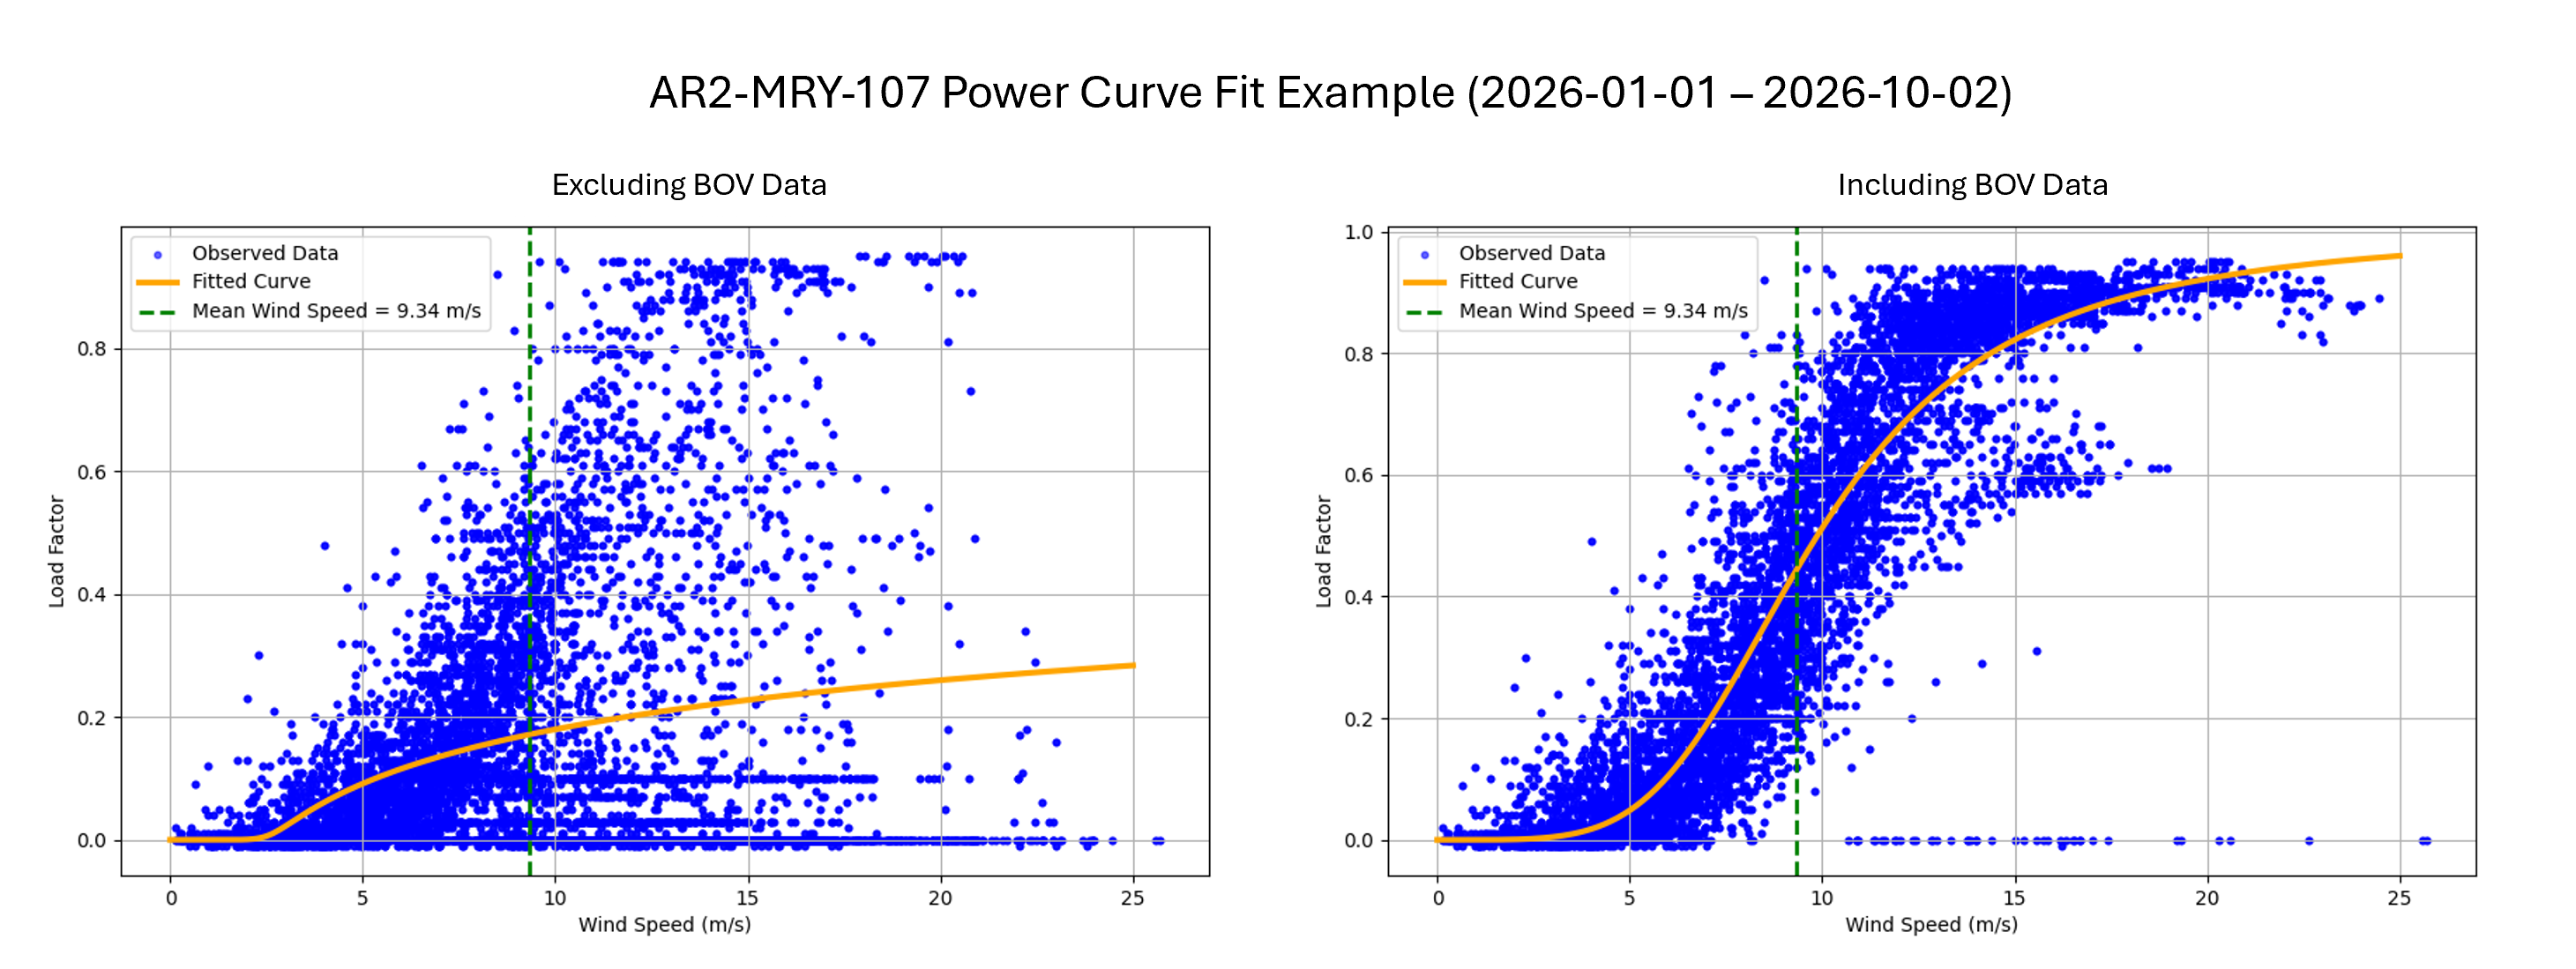

## 4) Import and Configure `WindCalibrator`

The key arguments are:

- `data_path`: base folder containing `plant/`, `generation/`, `era5/`
- `output_path`: where calibration outputs are written
- `visual_output`: save power curve PNG plots when `True`
- `stream_npy_output`: also save `Wind Streams.npy` when `True`

In [7]:
wc = WindCalibrator(
    data_path=str(DATA_PATH),
    output_path=OUTPUT_PATH,
    visual_output=True,
    stream_npy_output=True,
)

[INFO] - Plant data loaded: 166 plants, 23237.6 MW total capacity - [data_loader] - 2026-10-07 17:10:53
[INFO] - Generation data loaded: 325533 records, 51 plants - [data_loader] - 2026-10-07 17:10:53
[INFO] - ERA5 data loaded: 1 files, 6470 time periods - [data_loader] - 2026-10-07 17:10:55


In [8]:
print(wc.generation.data[wc.generation.data["plant_id"] == "AR2-MRY-207"])

          plant_id                      time  quantity
89362  AR2-MRY-207 2026-01-01 00:00:00+00:00     31.69
89363  AR2-MRY-207 2026-01-01 01:00:00+00:00     31.69
89364  AR2-MRY-207 2026-01-01 02:00:00+00:00     55.04
89365  AR2-MRY-207 2026-01-01 03:00:00+00:00    150.57
89366  AR2-MRY-207 2026-01-01 04:00:00+00:00    293.47
...            ...                       ...       ...
95740  AR2-MRY-207 2026-09-23 18:00:00+00:00     64.46
95741  AR2-MRY-207 2026-09-23 19:00:00+00:00     52.56
95742  AR2-MRY-207 2026-09-23 20:00:00+00:00     28.77
95743  AR2-MRY-207 2026-09-23 21:00:00+00:00     16.90
95744  AR2-MRY-207 2026-09-23 22:00:00+00:00     10.12

[6383 rows x 3 columns]


In [9]:
print(wc.generation.data[wc.generation.data["plant_id"] == "AR2-MRY-207"])

          plant_id                      time  quantity
89362  AR2-MRY-207 2026-01-01 00:00:00+00:00     31.69
89363  AR2-MRY-207 2026-01-01 01:00:00+00:00     31.69
89364  AR2-MRY-207 2026-01-01 02:00:00+00:00     55.04
89365  AR2-MRY-207 2026-01-01 03:00:00+00:00    150.57
89366  AR2-MRY-207 2026-01-01 04:00:00+00:00    293.47
...            ...                       ...       ...
95740  AR2-MRY-207 2026-09-23 18:00:00+00:00     64.46
95741  AR2-MRY-207 2026-09-23 19:00:00+00:00     52.56
95742  AR2-MRY-207 2026-09-23 20:00:00+00:00     28.77
95743  AR2-MRY-207 2026-09-23 21:00:00+00:00     16.90
95744  AR2-MRY-207 2026-09-23 22:00:00+00:00     10.12

[6383 rows x 3 columns]


## 5) Run Calibration

This executes the full workflow and writes outputs to `output_path`. 

The Calibration is performed in a step wise process:

- `Weibull Parameters`: This will calculate for each wind farm the parameters k and λ of the Weibull distribution of the wind speed frequency. This will then be fed into the calibration summary to calculate the average load factor.
  
- `Calibration Summary`: The model uses the five-parameter logistic function (5PL) to forecast wind output. This function combines the simplicity of one single analytical expression to accurately represent a wind power curve. The parameters are defined through a calibration process run over actual wind speed and generation data.

    The 5PL function is represented by the following equation:
        
    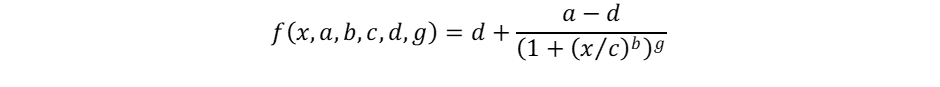

    The five parameters a, b, c, d and g can be interpreted as follows:

    a: lower bound representing minimum production

    b: slope of the curve

    c: inflection point of the curve

    d: upper bound representing maximum production

    g: asymmetry factor; curve is symmetric for g=1

    The effect of the variation of these parameters on the shape of a power curve defined by the 5PL function is shown below:

    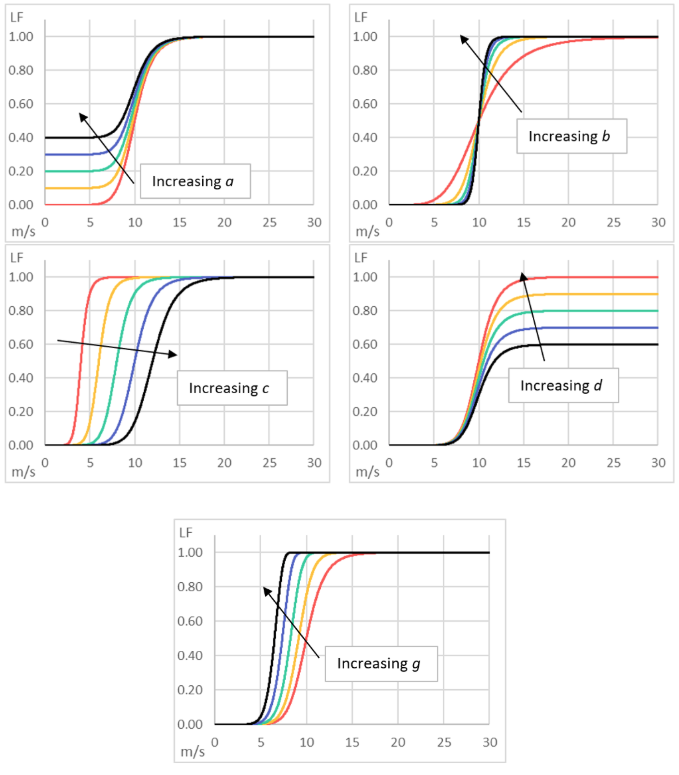

    After the determination of the five parameters, the analytical function can be easily applied to a hourly wind speed dataset to evaluate the corresponding hourly load factor.

    Practically what this process means is we can use the power curve to produce historical estimates (i.e. backcast), obtaining estimated load factors for plant locations in the past, as well as future estimates. Outputs from this process produce hourly load factors for each generator (aka wind streams) back to 1980.


- `Wind Speeds`: Using the ERA5 data and correpsonding longitude and latitudes of the generators from `plant/plant_data.csv`, hourly wind speeds are backcasted back to 1980 to present for each generator.
  
- `Wind Streams`: Using the wind speeds and generator specific power curves produced by the 5PL function, hourly load factors (wind streams) are calculated for each generator.
    
    > Note: With plants yet to start generating or newly operational plants, quite often we have minimal historical generation for which to derive a plant specific forecast. In other words, we don’t have enough generation data to confidently derive a power curve function, which can then be used to estimate historical values. In these instances, a generic power curve would be automatically applied to the wind speeds at the location of the plant to generate wind streams.

In [10]:
wc.calibrate()

[INFO] - Starting calibration process... - [wind_calibrator] - 2026-10-07 17:11:09
[INFO] - Combining final and initial release data for resource... - [wind_calibrator] - 2026-10-07 17:11:09
[INFO] - Extracting resource data for plants... - [wind_calibrator] - 2026-10-07 17:11:09
[INFO] - Written plant-wise resource dataset to ..\..\data\outputs\tutorials\wind_calibration\Wind Speeds.csv - [wind_calibrator] - 2026-10-07 17:11:11
[INFO] - Clculating historical load factors... - [wind_calibrator] - 2026-10-07 17:11:11
[INFO] - Fitting probability distribution to historical load factors... - [wind_calibrator] - 2026-10-07 17:11:11
[INFO] - Written historical load factor parameters to ..\..\data\outputs\tutorials\wind_calibration\Weibull Params.csv - [wind_calibrator] - 2026-10-07 17:11:12
[INFO] - Estimating long-term load factors for plants... - [wind_calibrator] - 2026-10-07 17:11:12
[INFO] - AAA-ACH-183 - [wind_calibrator] - 2026-10-07 17:11:12
[INFO] - AAA-BAD-185 - [wind_calibrator] 

c:\Users\ObasiH\Repos\rencal\.venv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in logaddexp
  result = getattr(ufunc, method)(*inputs, **kwargs)


## 6) Inspect Generated Outputs

After calibration completes, this notebook should produce:

- `Calibration Summary.csv`
- `Weibull Params.csv`
- `Wind Speeds.csv`
- `Wind Streams.parquet`
- `PowerCurveFit_*.png` (if `visual_output=True`)
- `Wind Streams.npy` (if `stream_npy_output=True`)

In [11]:
# list of the generated outputs
sorted([p.name for p in OUTPUT_PATH.glob("*")])

['Calibration Summary.csv',
 'PowerCurveFit_AAA-ACH-183.png',
 'PowerCurveFit_AAA-BAD-185.png',
 'PowerCurveFit_AAA-BAN-189.png',
 'PowerCurveFit_AAA-BAN-192.png',
 'PowerCurveFit_AAA-COI-196.png',
 'PowerCurveFit_AAA-DOR-182.png',
 'PowerCurveFit_AAA-NAN-184.png',
 'PowerCurveFit_AAA-NEA-195.png',
 'PowerCurveFit_AAA-PNE-187.png',
 'PowerCurveFit_AAA-SOL-181.png',
 'PowerCurveFit_AR2-HRN-106.png',
 'PowerCurveFit_AR2-HRN-206.png',
 'PowerCurveFit_AR2-HRN-306.png',
 'PowerCurveFit_AR2-MRY-107.png',
 'PowerCurveFit_AR2-MRY-207.png',
 'PowerCurveFit_AR2-MRY-307.png',
 'PowerCurveFit_AR2-TKN-103.png',
 'PowerCurveFit_AR2-TKN-203.png',
 'PowerCurveFit_AR2-TKN-303.png',
 'PowerCurveFit_AR3-SOW-101.png',
 'PowerCurveFit_AR3-SOW-102.png',
 'PowerCurveFit_AR3-SOW-103.png',
 'PowerCurveFit_AR4-BCW-610.png',
 'PowerCurveFit_AR4-CWS-610.png',
 'PowerCurveFit_AR4-HHR-610.png',
 'PowerCurveFit_AR4-KWE-610.png',
 'PowerCurveFit_AR5-BWI-610.png',
 'PowerCurveFit_AR6-BEN-610.png',
 'PowerCurveFit_AR6-

### Output: 1 - Weibull Parameters

Weilbull Parameters CSV displaying each wind farms parameters k and λ of the Weibull distribution of the wind speed frequency.

In [12]:
weibull = pd.read_csv(OUTPUT_PATH / "Weibull Params.csv")

display(weibull)

,plant_id,wind_speed_mean,wind_speed_stdev,k,lambda
0,AR5-BWI-610,6.885670,3.042651,2.405069,7.759253
1,AR3-SOW-102,9.679855,4.287569,2.405630,10.913685
2,AR2-MRY-107,9.340187,4.419719,2.231136,10.539468
3,AAA-PNE-187,7.929395,3.536878,2.378671,8.934141
4,AAA-COI-196,6.263965,2.884331,2.301630,7.063936
5,AAA-BAN-192,7.115717,3.080255,2.462674,8.015078
6,AAA-NEA-195,8.447882,3.895527,2.292763,9.523178
7,AR4-KWE-610,7.914161,3.534817,2.364521,8.910112
8,AR4-BCW-610,7.115717,3.080376,2.462674,8.015079
9,AR6-CRI-610,8.447882,3.895679,2.292761,9.523161


### Output: 2 - Calibration Summary

Calibration summary CSV containing 5-parameters function parameters and generator estimated load factors

In [ ]:
summary = pd.read_csv(OUTPUT_PATH / "Calibration Summary.csv")

display(summary)

### Output: 3 - Wind Speeds

Hourly windspeeds from 1980-01-01 to present for each plant_id

In [ ]:
wind_speeds = pd.read_csv(OUTPUT_PATH / "Wind Speeds.csv")

display(wind_speeds)

### Output: 4 - Wind Streams

Hourly wind streams (Load Factors) from 1980-01-01 to present for each plant_id

In [13]:
wind_streams = pd.read_parquet(OUTPUT_PATH / "Wind Streams.parquet")

display(wind_streams)

,Times,AAA-ACH-183,AAA-BAD-185,AAA-BAN-189,AAA-BAN-190,AAA-BAN-192,AAA-BRE-177,AAA-CLO-186,AAA-COI-196,AAA-COM-191,...,INV-BEA-002,INV-BUR-001,INV-DUD-001,INV-DUD-002,INV-DUD-003,INV-HOR-001,INV-HOR-002,INV-HOR-003,INV-WAL-001,INV-WAL-002
0,2026-01-01 00:00:00+00:00,0.954273,0.852069,0.601931,0.553500,0.601773,0.424067,0.424067,0.553339,0.452029,...,0.904742,0.880058,0.987290,0.981839,0.980723,0.994125,0.994655,0.983489,0.882412,0.973377
1,2026-01-01 01:00:00+00:00,0.968348,0.873239,0.559949,0.564372,0.576911,0.427521,0.427521,0.559116,0.458847,...,0.909232,0.911069,0.994345,0.991304,0.992154,0.995337,0.995258,0.985282,0.905198,0.985791
2,2026-01-01 02:00:00+00:00,0.980672,0.896173,0.486921,0.563802,0.521124,0.425147,0.425147,0.522679,0.466541,...,0.920027,0.931692,0.998295,0.997072,0.997644,0.993502,0.994671,0.984007,0.907251,0.986711
3,2026-01-01 03:00:00+00:00,0.975737,0.886274,0.458293,0.563139,0.499058,0.439617,0.439617,0.510887,0.491578,...,0.922074,0.942483,0.999360,0.998796,0.999122,0.994098,0.996435,0.986205,0.910026,0.987901
4,2026-01-01 04:00:00+00:00,0.969568,0.875277,0.449396,0.523763,0.489074,0.453832,0.453832,0.522847,0.509594,...,0.915532,0.955840,0.999546,0.999117,0.999409,0.998554,0.998504,0.995927,0.923041,0.992657
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6465,2026-09-27 09:00:00+00:00,0.789540,0.692966,0.432132,0.411648,0.479222,0.518912,0.518912,0.317611,0.302680,...,0.823847,0.826583,0.450725,0.428702,0.447869,0.532280,0.475863,0.529972,0.851736,0.950806
6466,2026-09-27 10:00:00+00:00,0.831411,0.727503,0.368973,0.495235,0.438949,0.539353,0.539353,0.356898,0.291010,...,0.831039,0.806574,0.430677,0.409408,0.485134,0.396918,0.292913,0.436889,0.852359,0.951325
6467,2026-09-27 11:00:00+00:00,0.792075,0.695013,0.339340,0.503224,0.436187,0.604428,0.604428,0.287199,0.395769,...,0.817933,0.875019,0.528191,0.503668,0.580931,0.470054,0.368471,0.521452,0.852979,0.951837
6468,2026-09-27 12:00:00+00:00,0.702937,0.624982,0.363882,0.589658,0.485461,0.559920,0.559920,0.240310,0.502648,...,0.796390,0.923917,0.562032,0.536655,0.572809,0.536376,0.411275,0.586696,0.870119,0.965083


### Output: 5 - Wind Streams vs Actual Generation

Wind power curve plot outputs showing the relationship between estimated and actual load factors for a given plant_id. Estimated load factors are taken from wind_streams, while actual load factors are calculated from metered generation data as quantity / capacity. The two series are merged on cfd_id and time, filtered to a single plant, and plotted as a time series comparison.

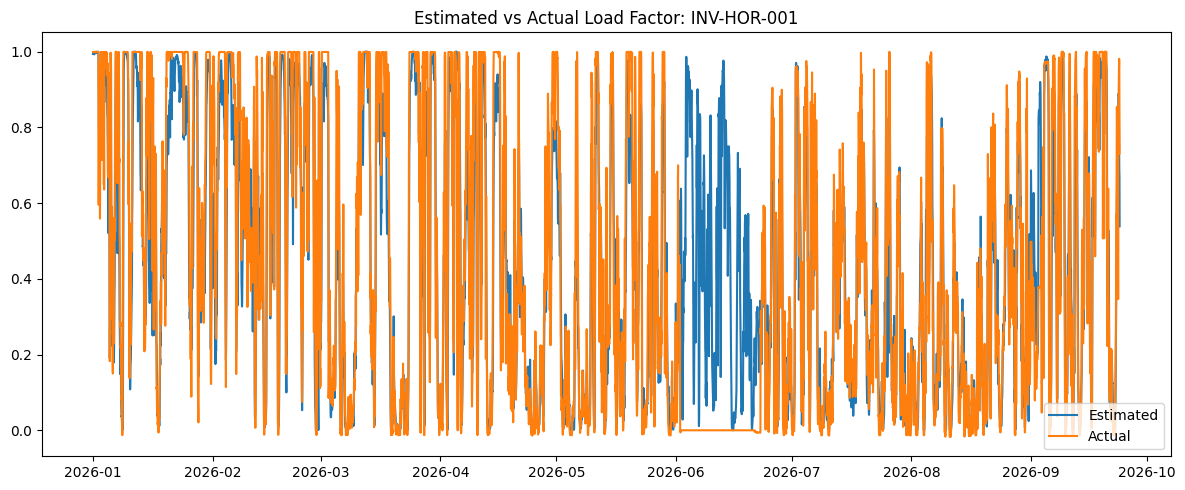

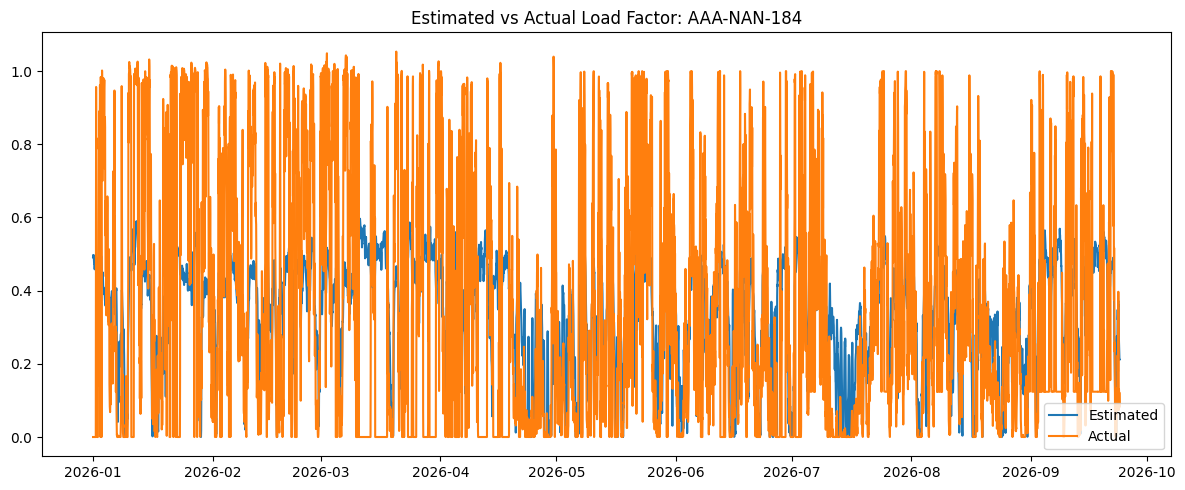

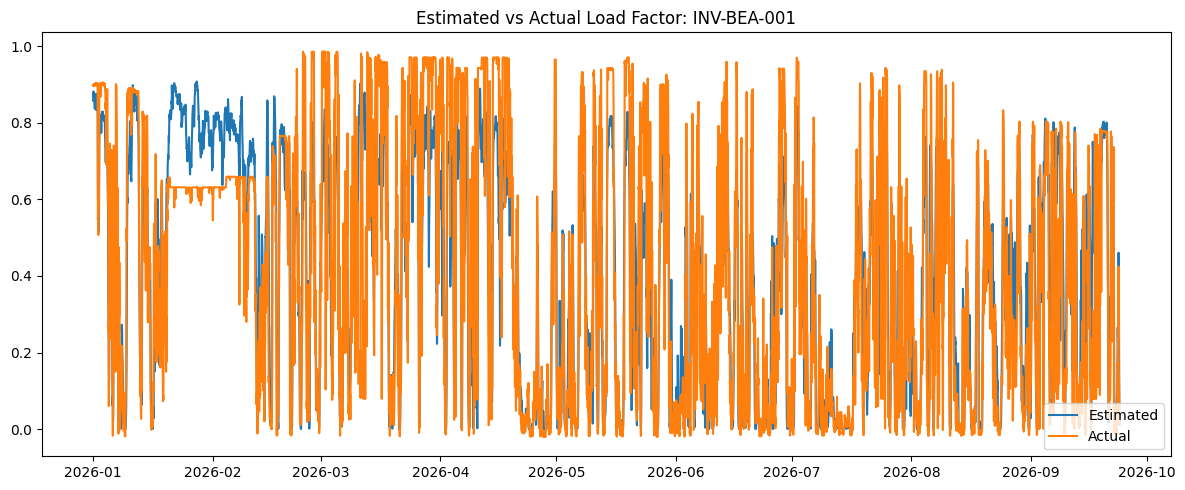

In [14]:
wind_long = wind_streams.rename(columns={"Times": "time"}).melt(
    id_vars="time",
    var_name="cfd_id",
    value_name="estimated_load_factor",
)

wind_long["time"] = pd.to_datetime(wind_long["time"], utc=True)
generation_data["time"] = pd.to_datetime(generation_data["time"], utc=True)

generation_data_capacity = generation_data.merge(
    plant_data[["cfd_id", "capacity"]],
    on="cfd_id",
    how="inner",
)

generation_data_capacity["actual_load_factor"] = (
    generation_data_capacity["quantity"] / generation_data_capacity["capacity"]
)

df = wind_long.merge(
    generation_data_capacity[["cfd_id", "time", "actual_load_factor"]],
    on=["cfd_id", "time"],
    how="inner",
)

plant_ids = ["INV-HOR-001", "AAA-NAN-184", "INV-BEA-001"]

for plant_id in plant_ids:
    plot_df = df[df["cfd_id"] == plant_id].sort_values("time")

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(plot_df["time"], plot_df["estimated_load_factor"], label="Estimated")
    ax.plot(plot_df["time"], plot_df["actual_load_factor"], label="Actual")
    ax.set_title(f"Estimated vs Actual Load Factor: {plant_id}")
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

### Output: 6 - Power Curves

Wind power curve plot outputs showing the relationship between wind speed and load factor for each plant_id, with fitted power curves alongside average wind speed profiles.

Found 45 PNG files.



### PowerCurveFit_AAA-ACH-183.png

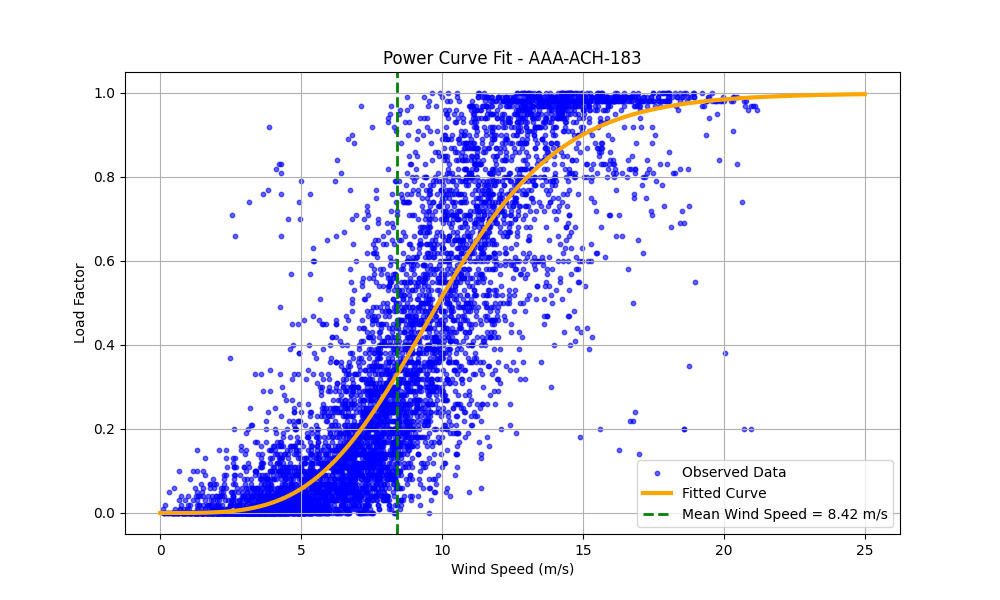

### PowerCurveFit_AAA-BAD-185.png

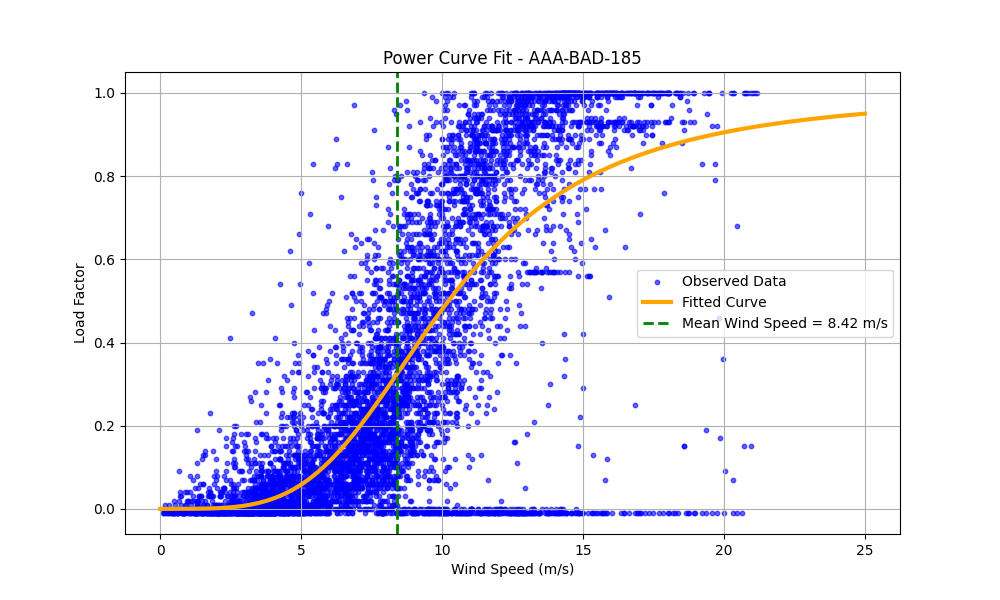

### PowerCurveFit_AAA-BAN-189.png

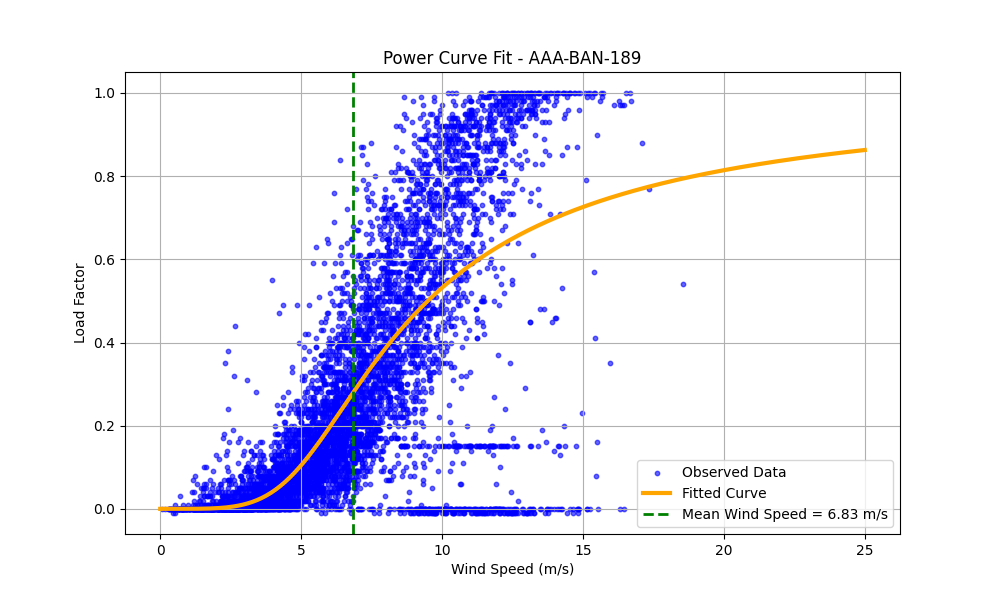

### PowerCurveFit_AAA-BAN-192.png

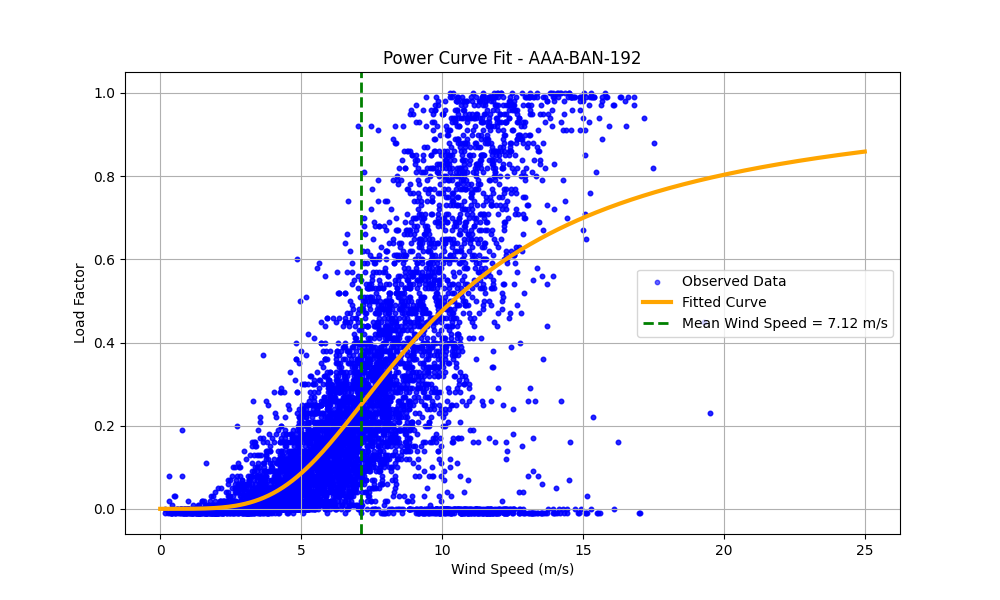

### PowerCurveFit_AAA-COI-196.png

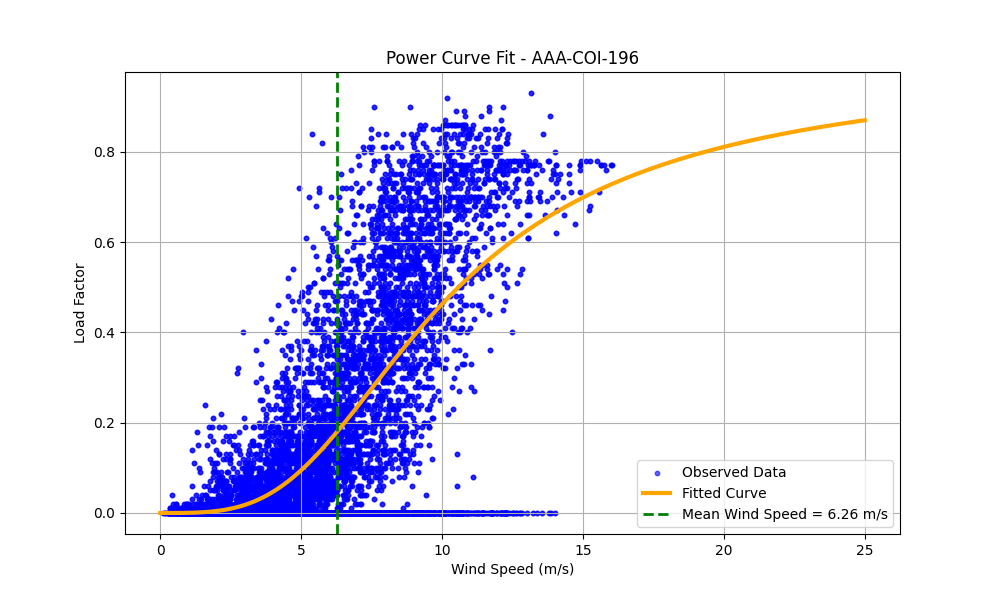

### PowerCurveFit_AAA-DOR-182.png

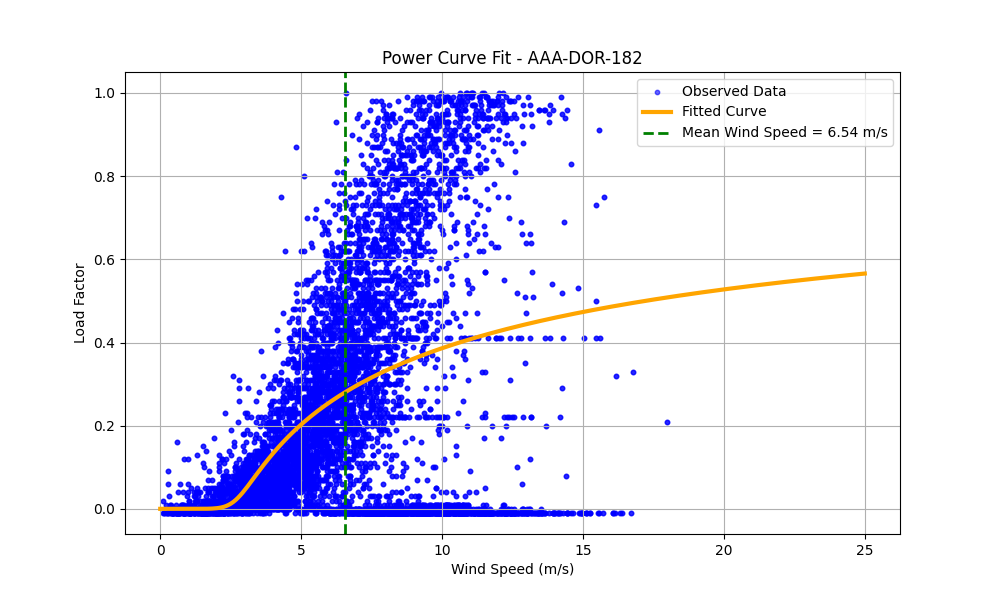

### PowerCurveFit_AAA-NAN-184.png

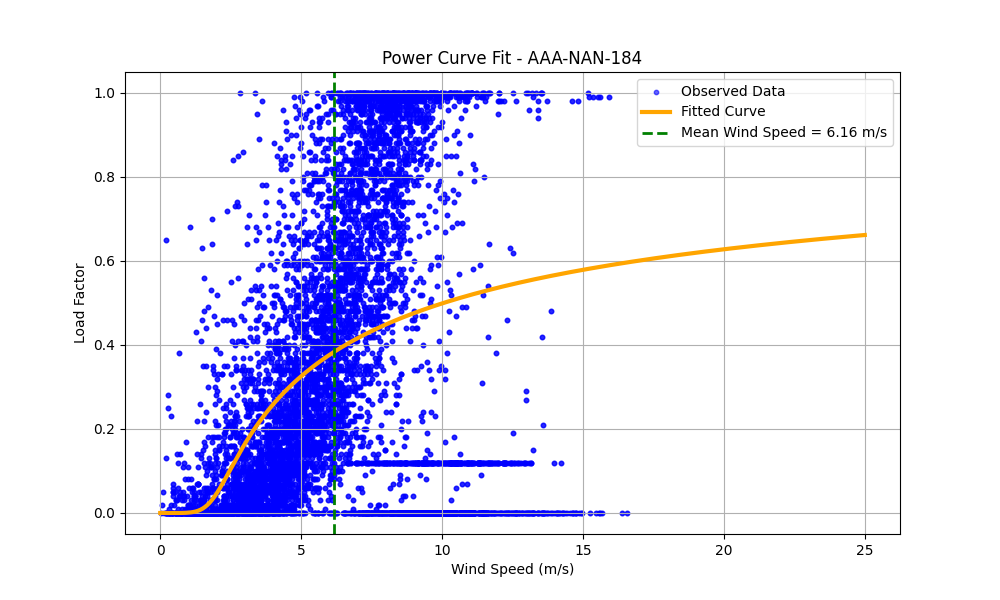

### PowerCurveFit_AAA-NEA-195.png

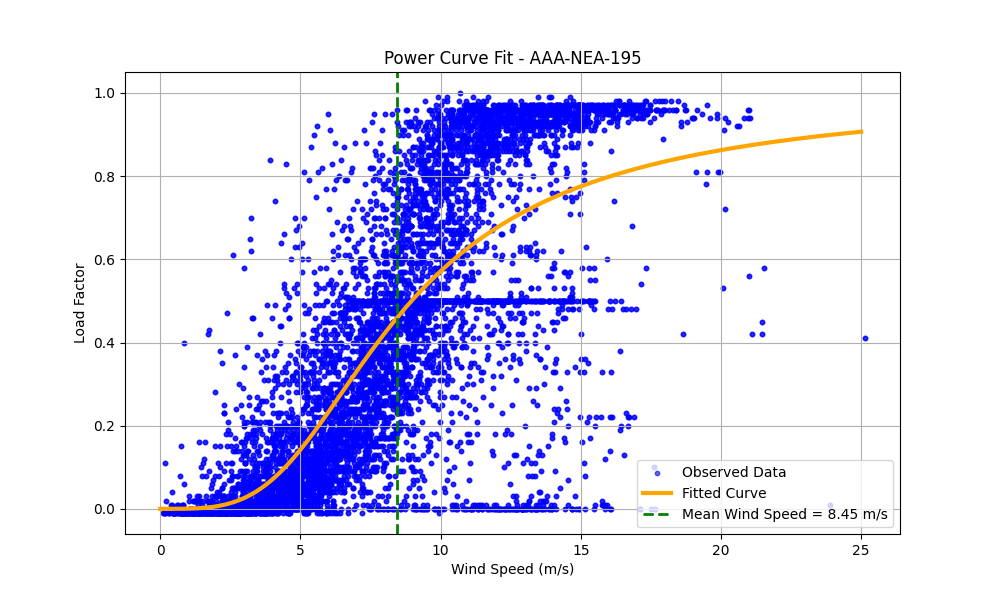

### PowerCurveFit_AAA-PNE-187.png

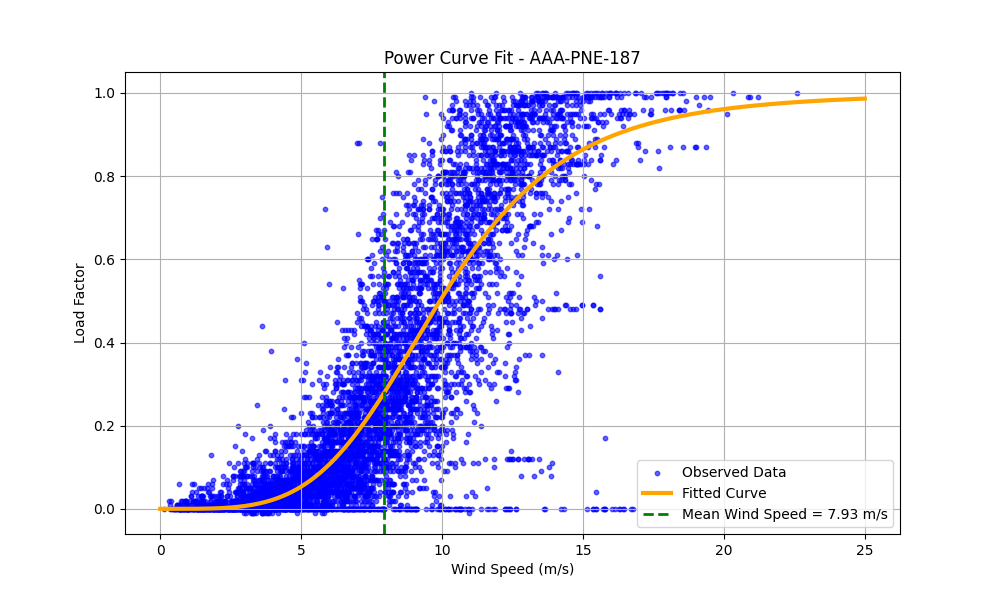

### PowerCurveFit_AAA-SOL-181.png

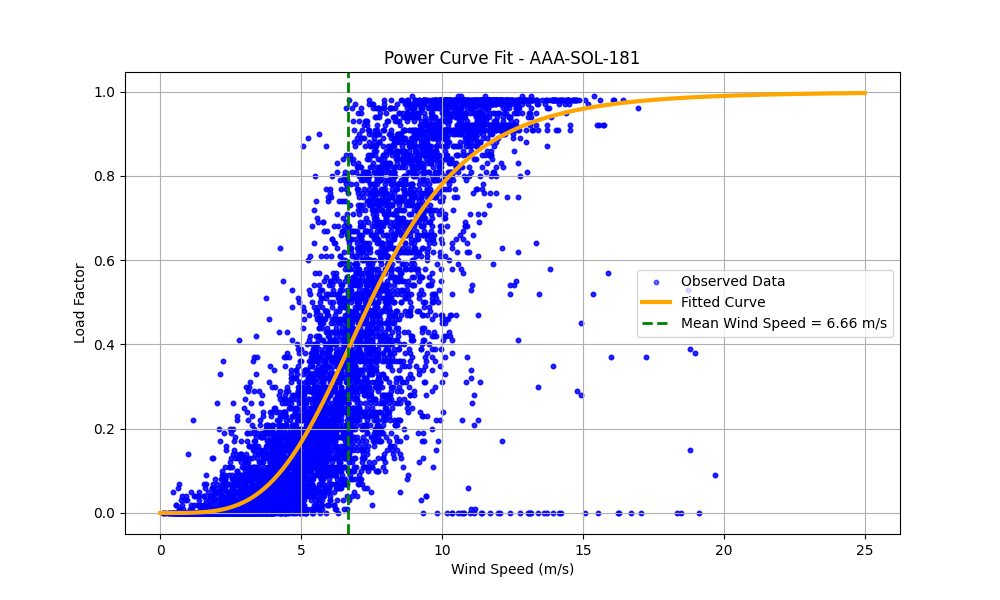

### PowerCurveFit_AR2-HRN-106.png

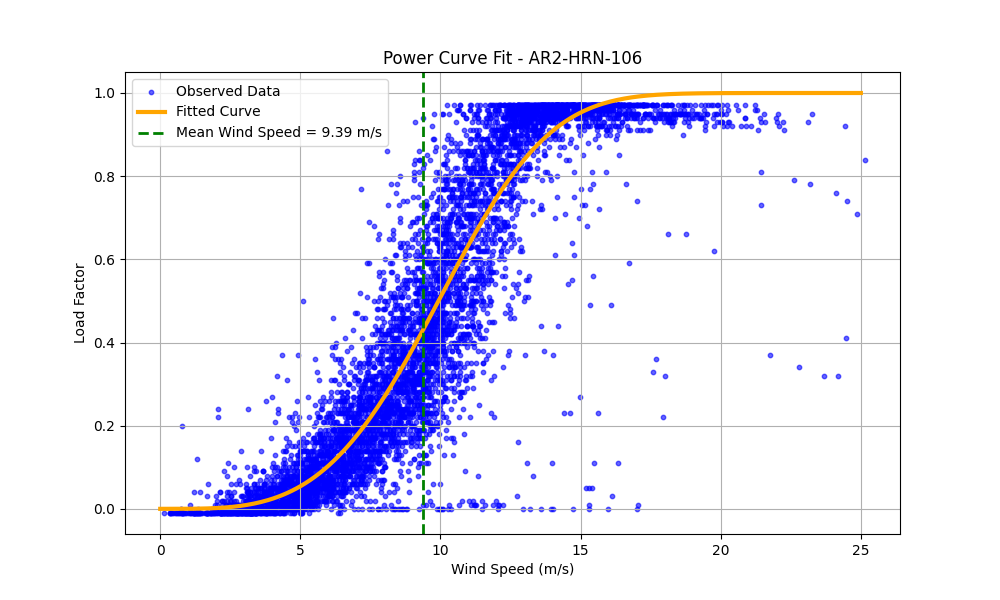

### PowerCurveFit_AR2-HRN-206.png

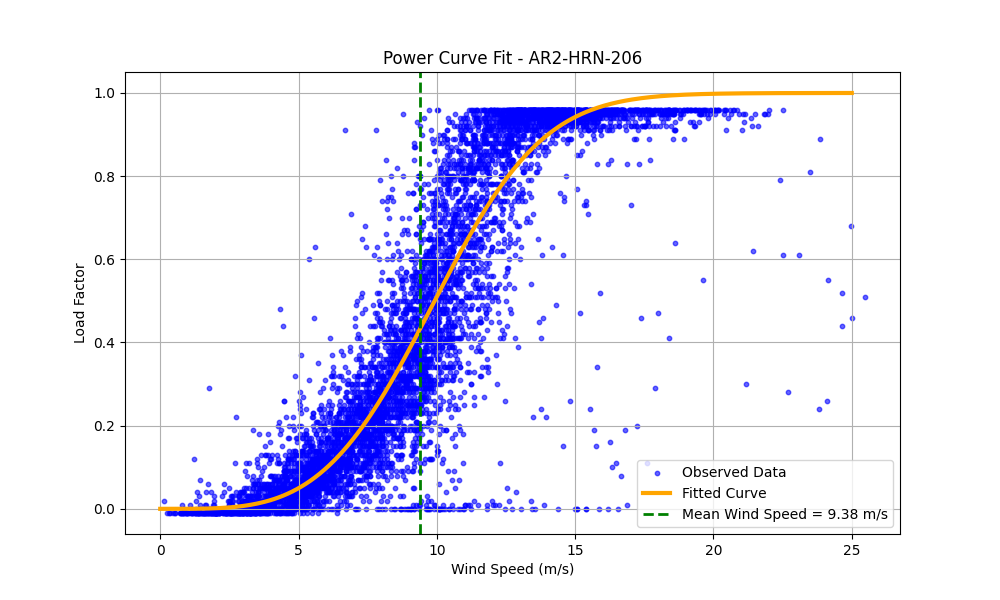

### PowerCurveFit_AR2-HRN-306.png

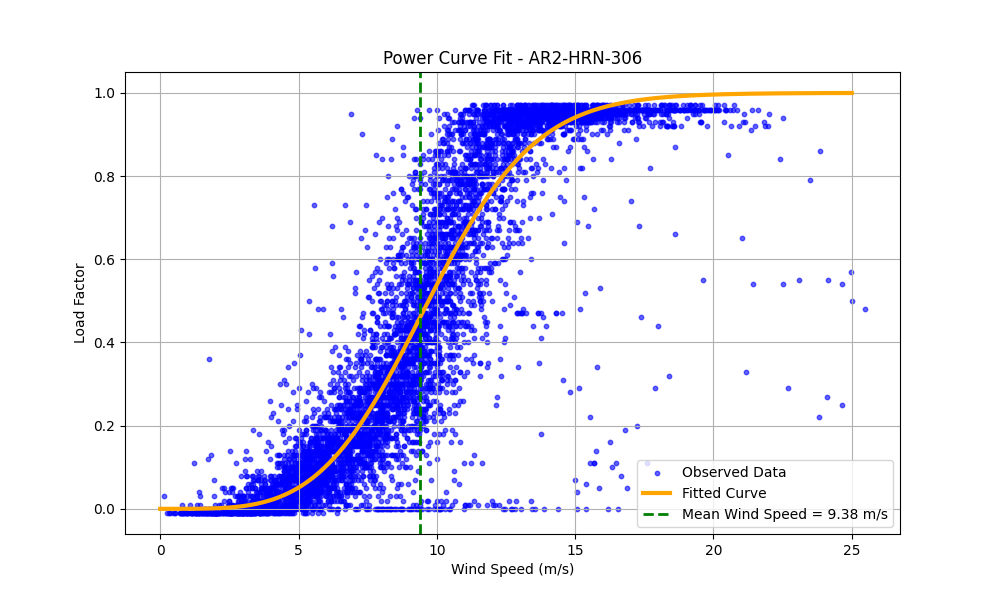

### PowerCurveFit_AR2-MRY-107.png

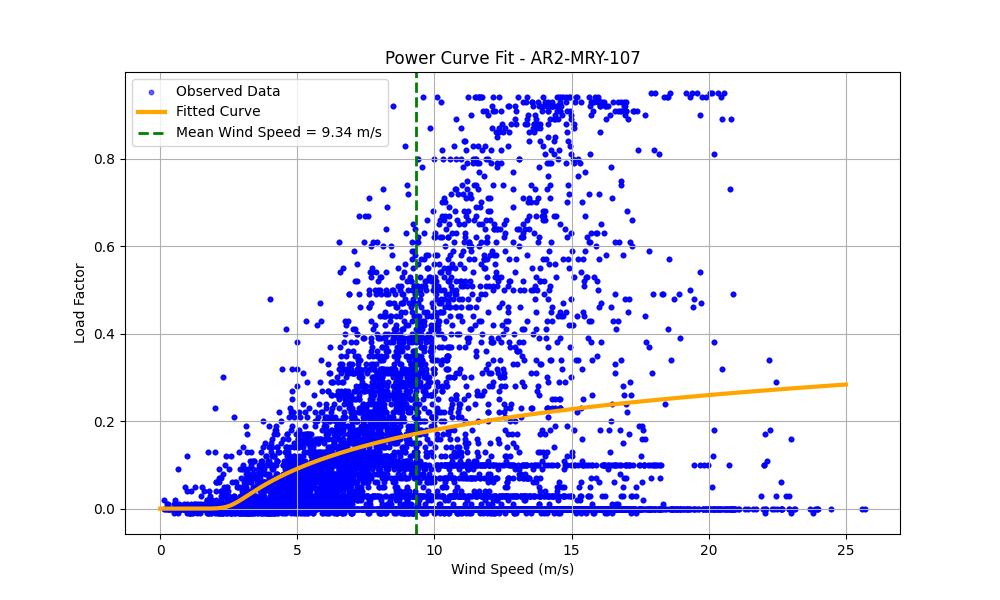

### PowerCurveFit_AR2-MRY-207.png

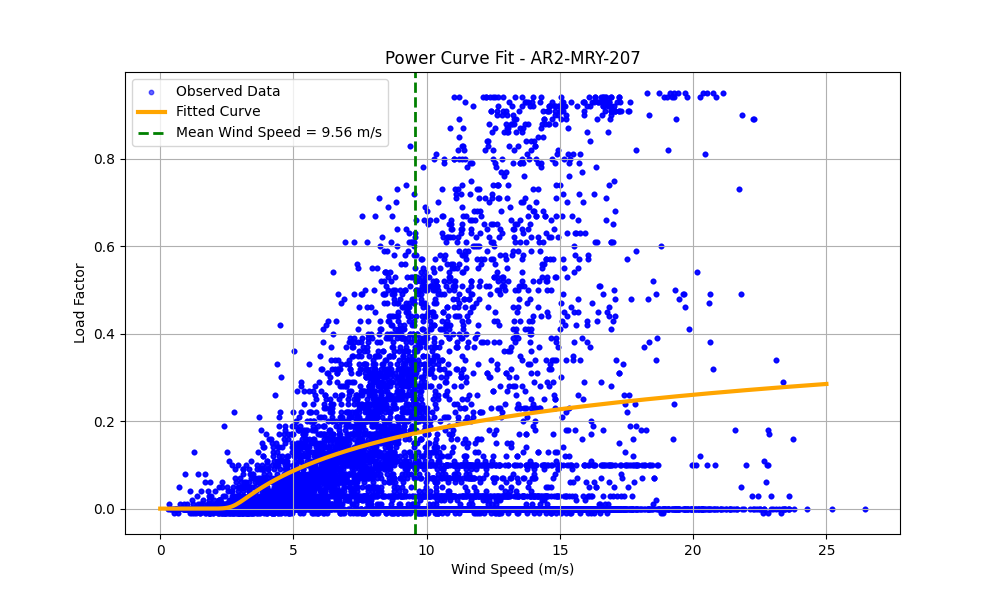

### PowerCurveFit_AR2-MRY-307.png

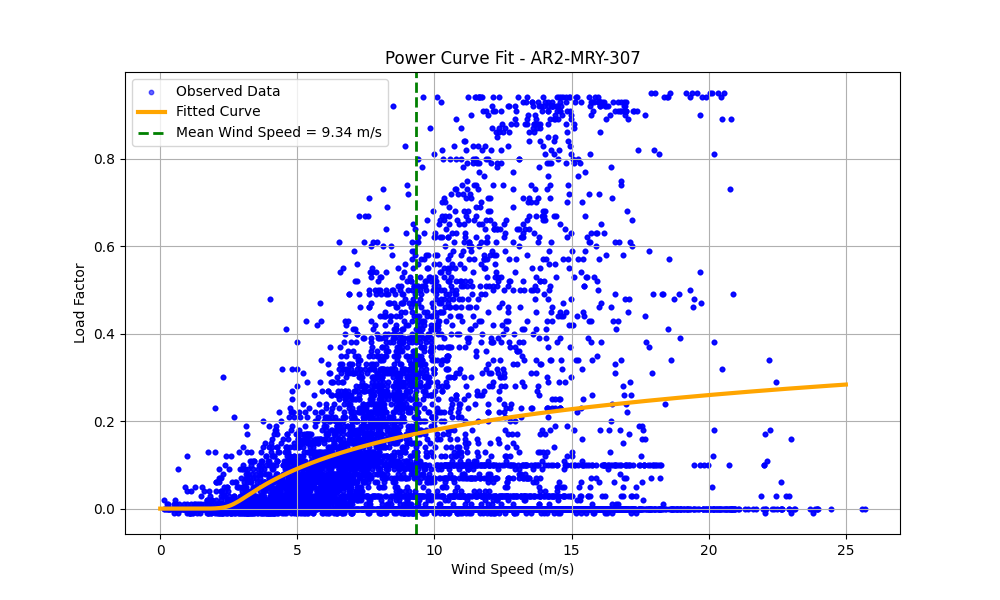

### PowerCurveFit_AR2-TKN-103.png

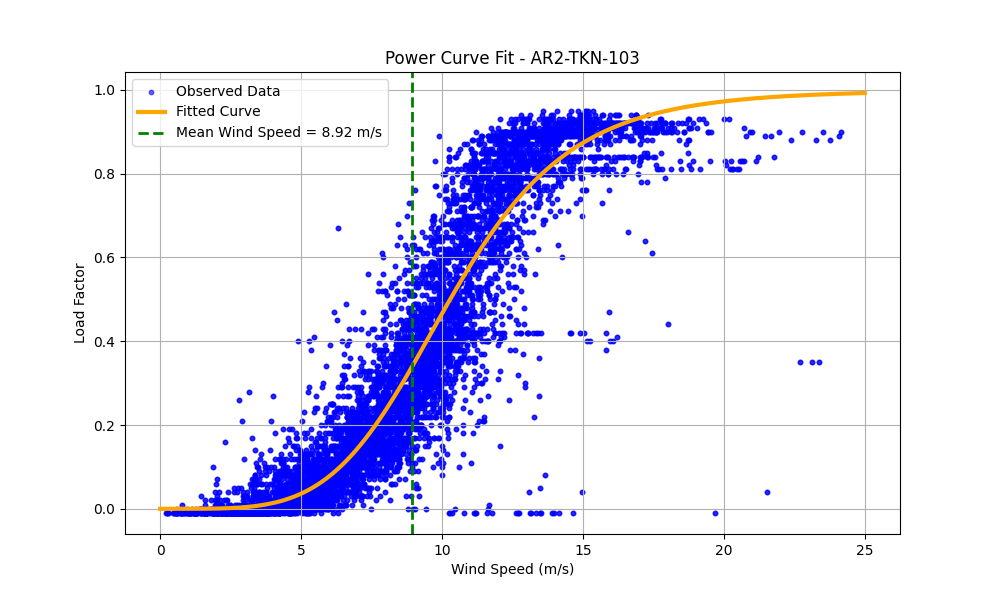

### PowerCurveFit_AR2-TKN-203.png

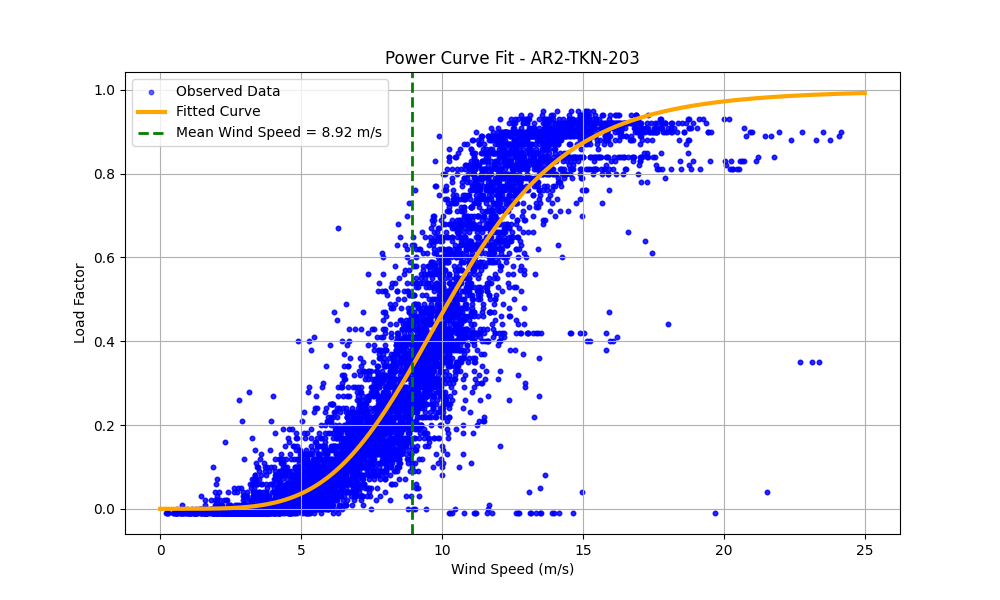

### PowerCurveFit_AR2-TKN-303.png

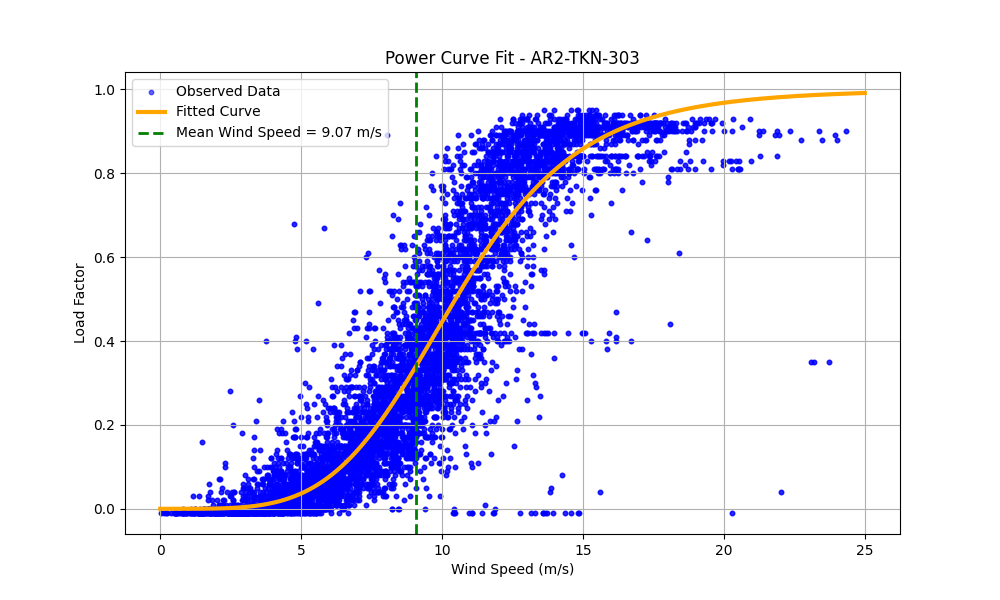

### PowerCurveFit_AR3-SOW-101.png

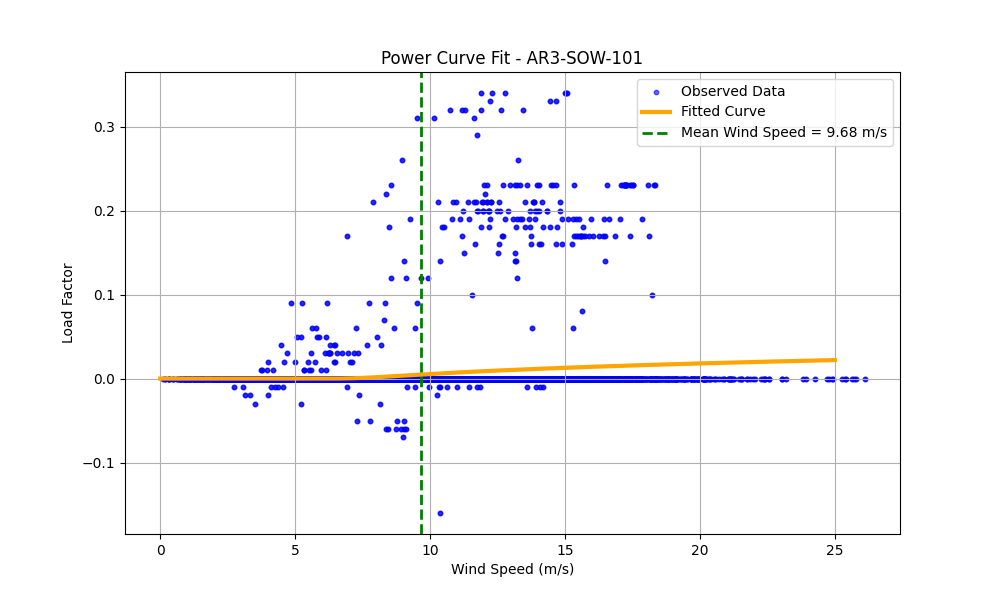

### PowerCurveFit_AR3-SOW-102.png

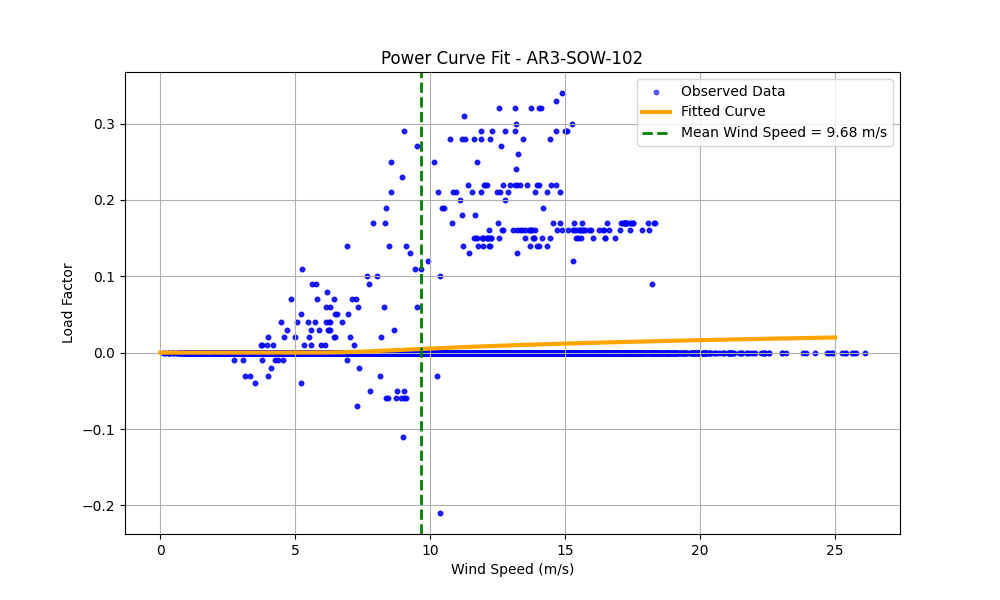

### PowerCurveFit_AR3-SOW-103.png

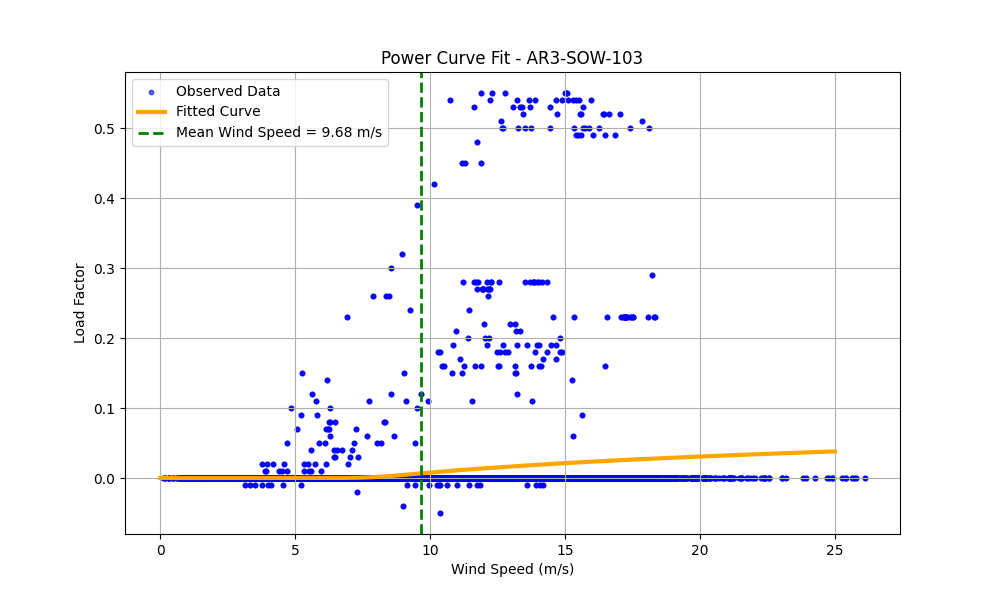

### PowerCurveFit_AR4-BCW-610.png

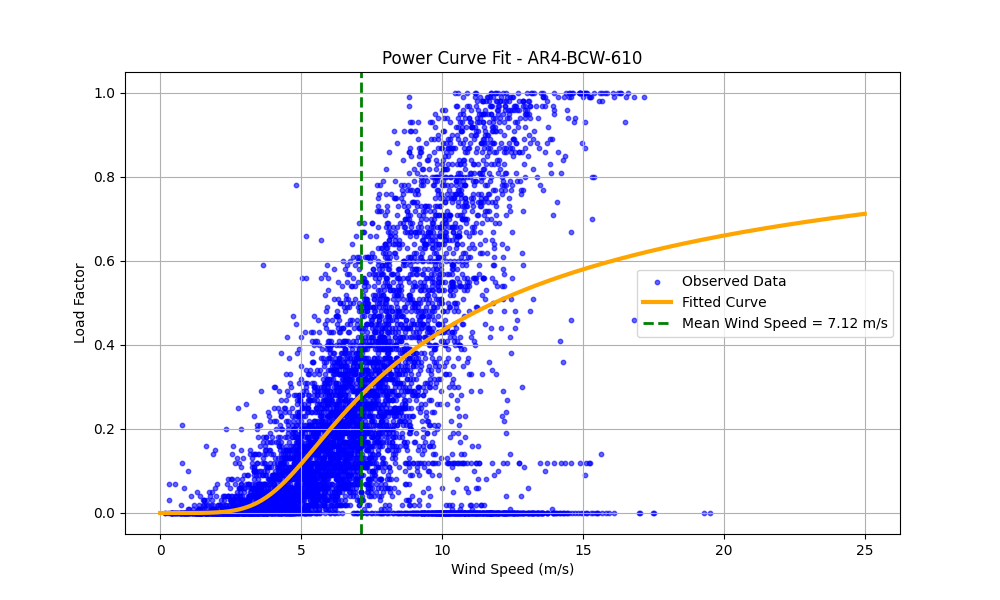

### PowerCurveFit_AR4-CWS-610.png

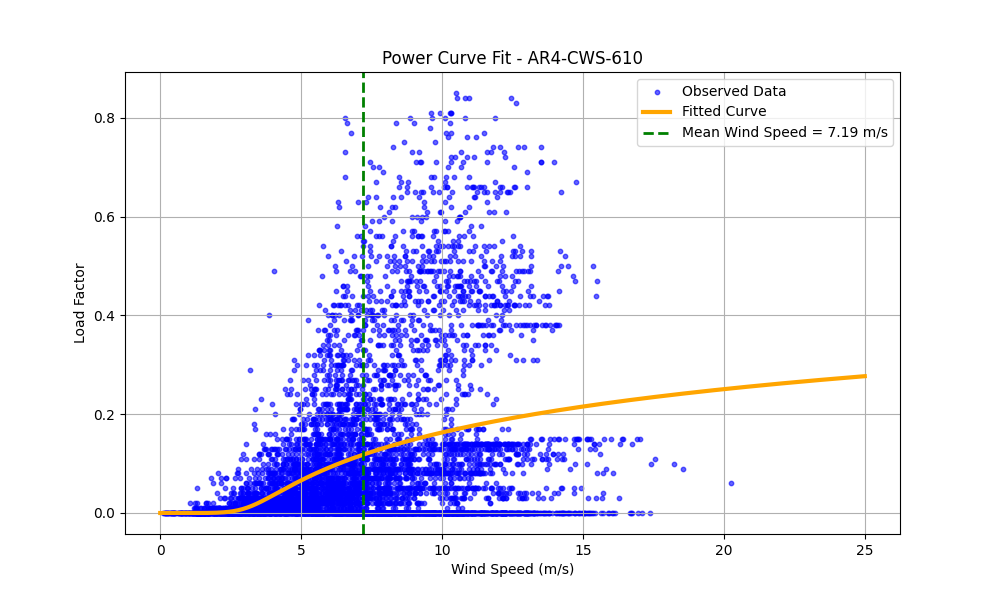

### PowerCurveFit_AR4-HHR-610.png

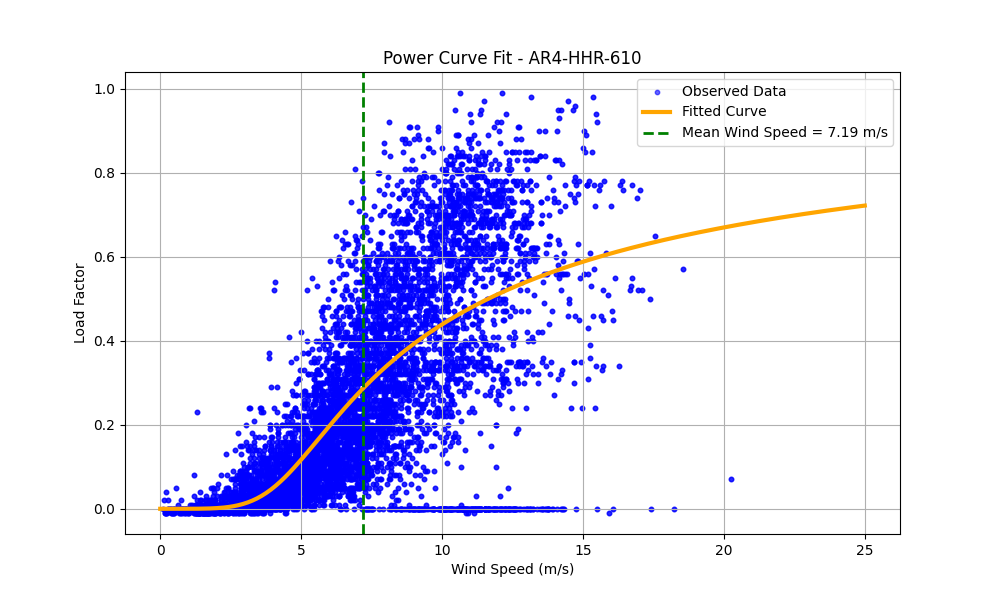

### PowerCurveFit_AR4-KWE-610.png

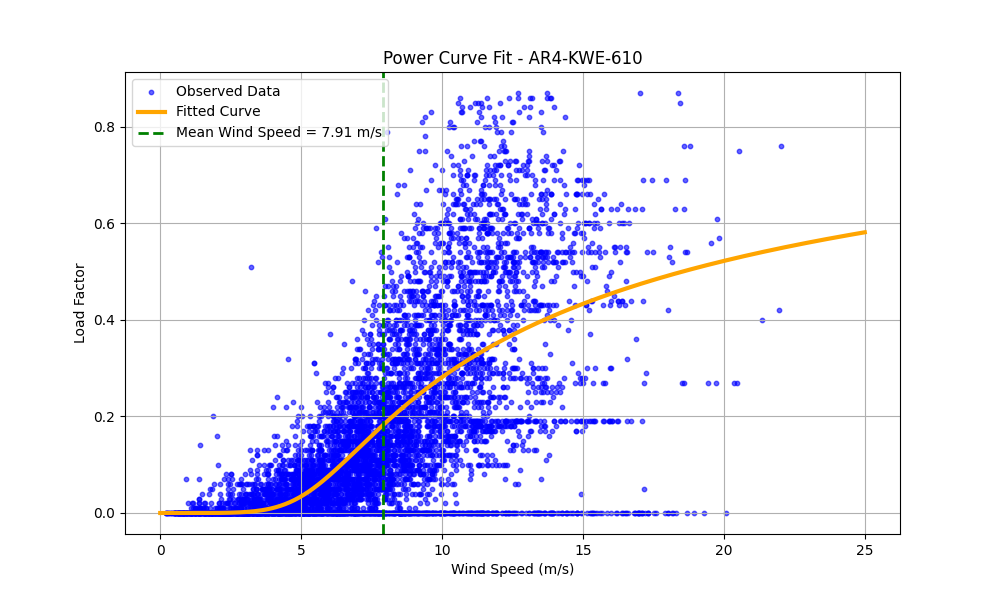

### PowerCurveFit_AR5-BWI-610.png

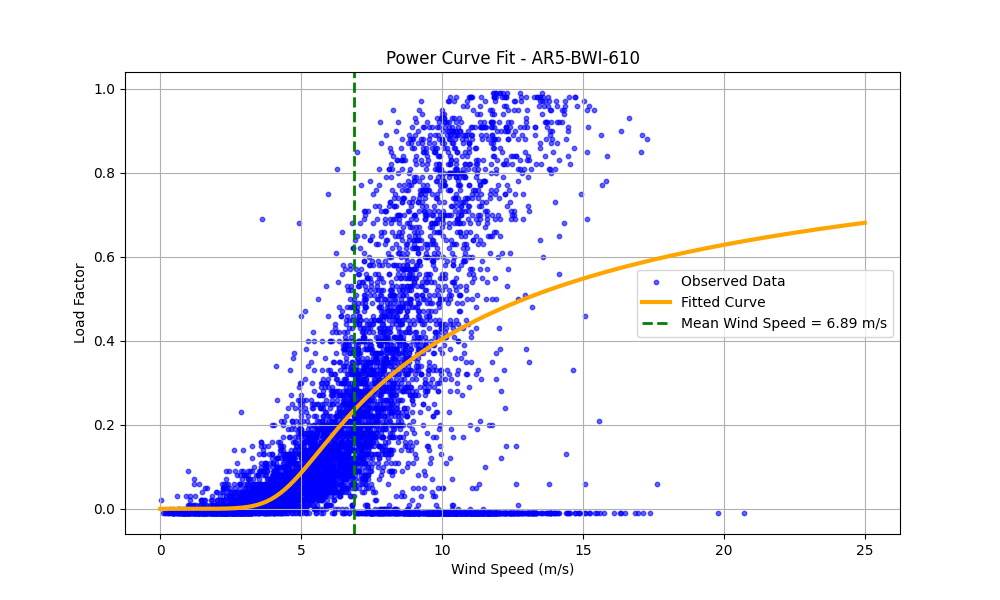

### PowerCurveFit_AR6-BEN-610.png

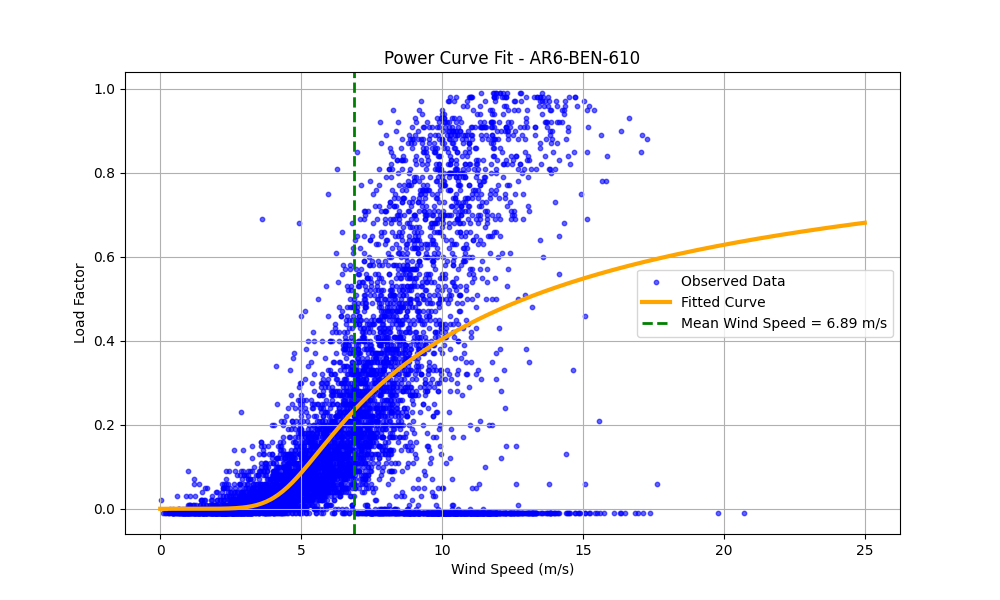

### PowerCurveFit_AR6-BWA-610.png

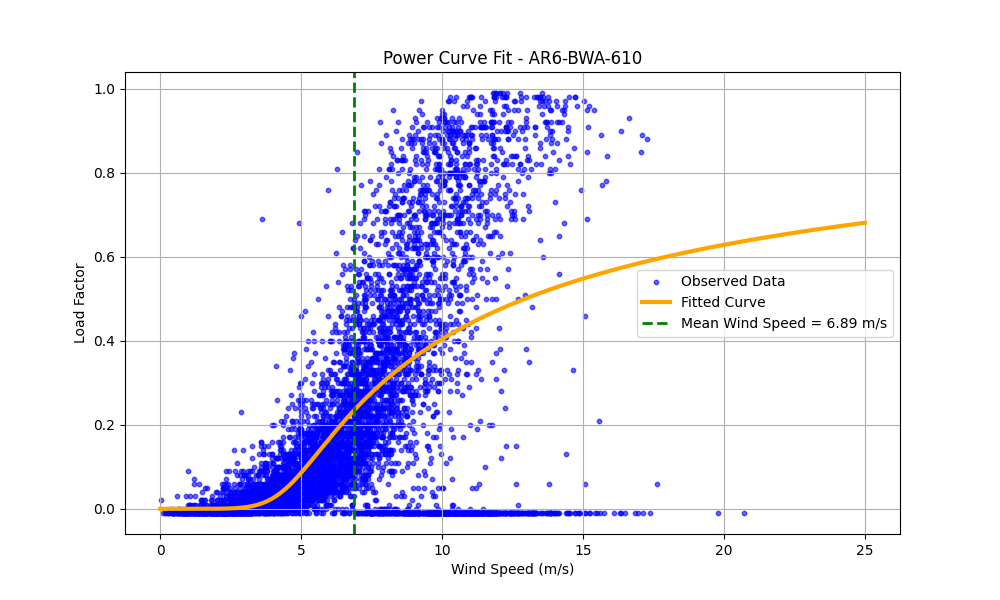

### PowerCurveFit_AR6-CRI-610.png

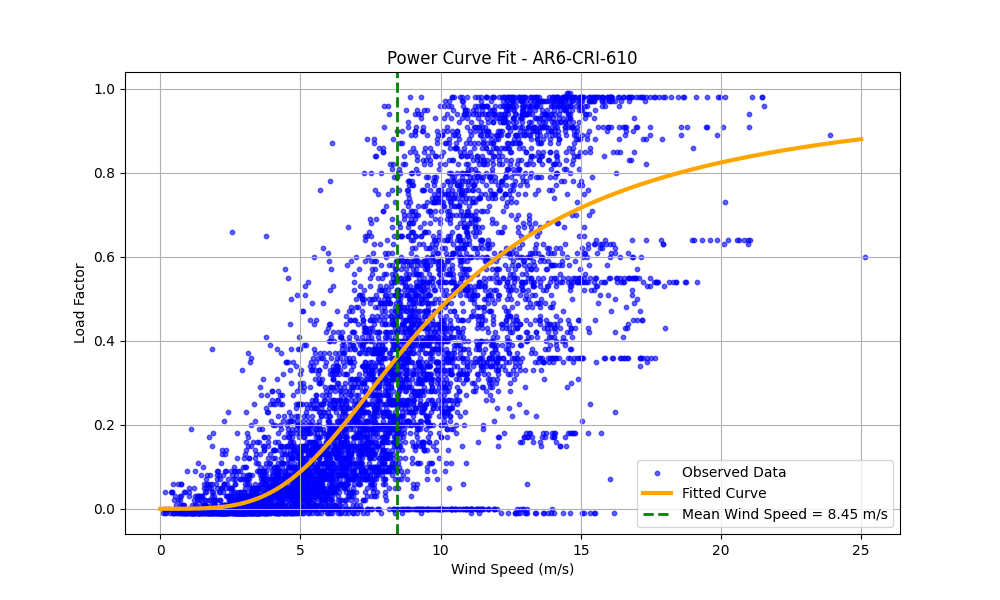

### PowerCurveFit_AR6-KHW-600.png

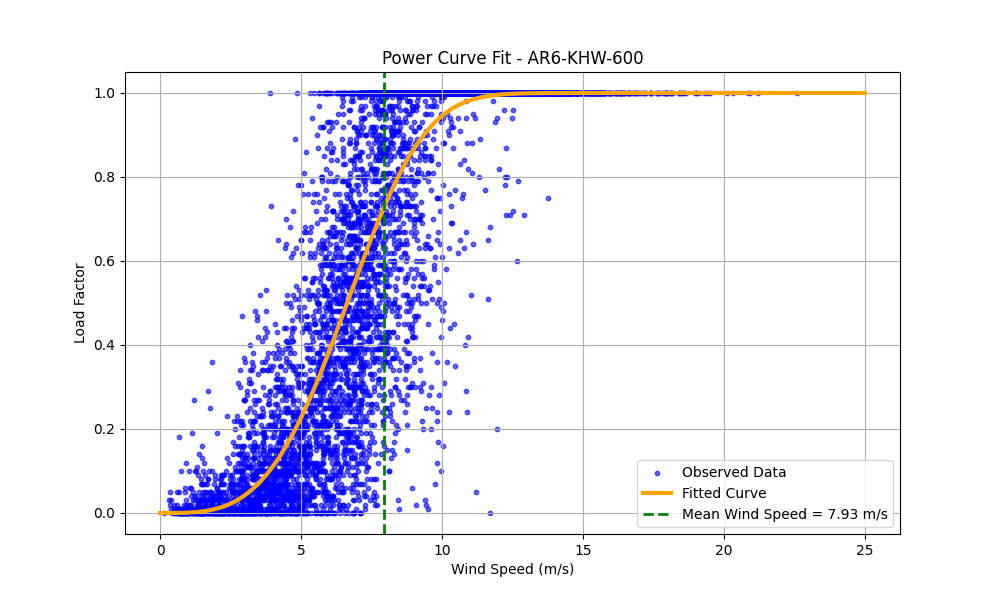

### PowerCurveFit_CAA-EAS-166.png

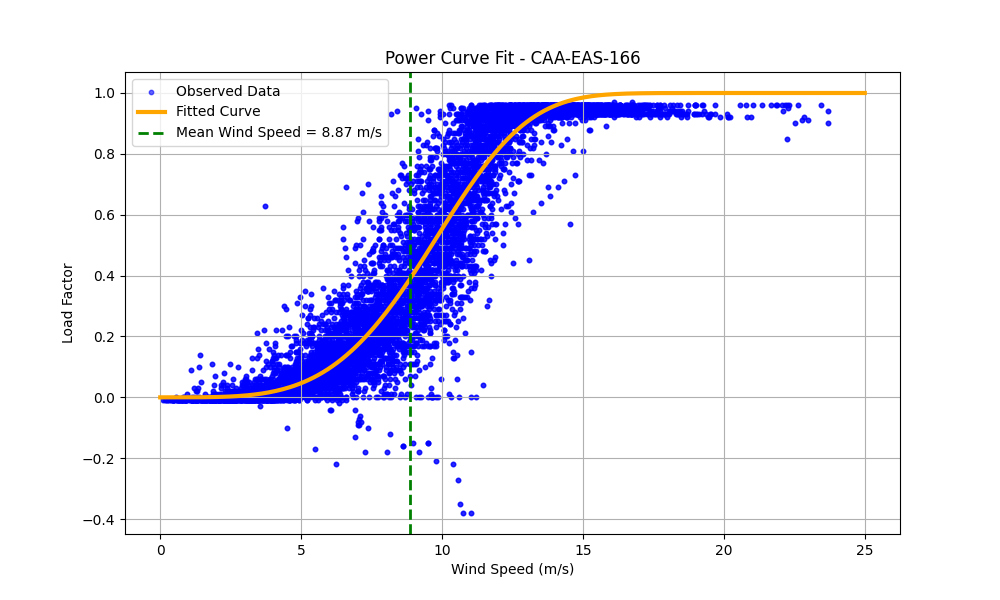

### PowerCurveFit_CAA-EAS-167.png

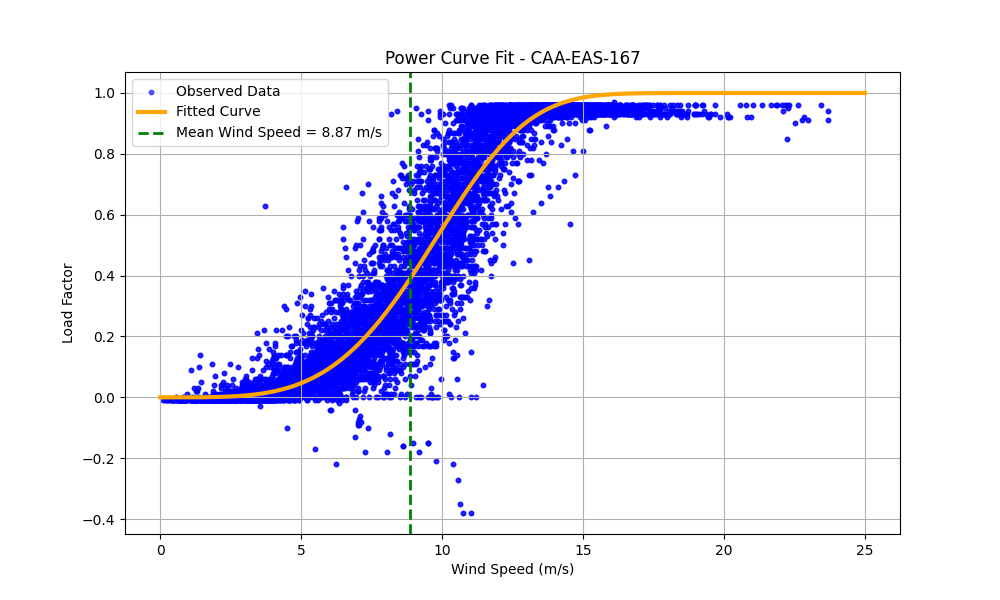

### PowerCurveFit_CAA-EAS-168.png

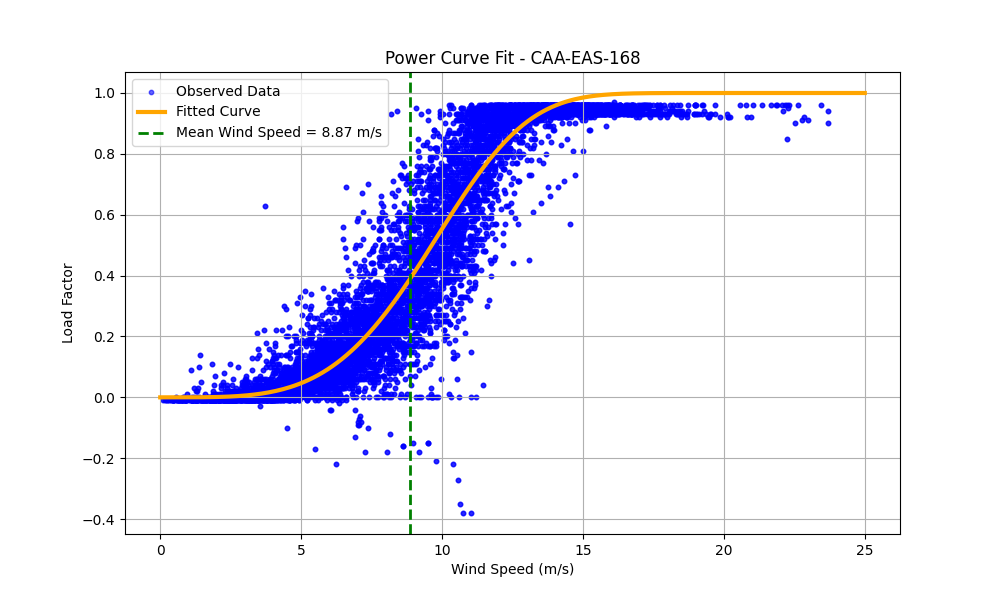

### PowerCurveFit_INV-BEA-001.png

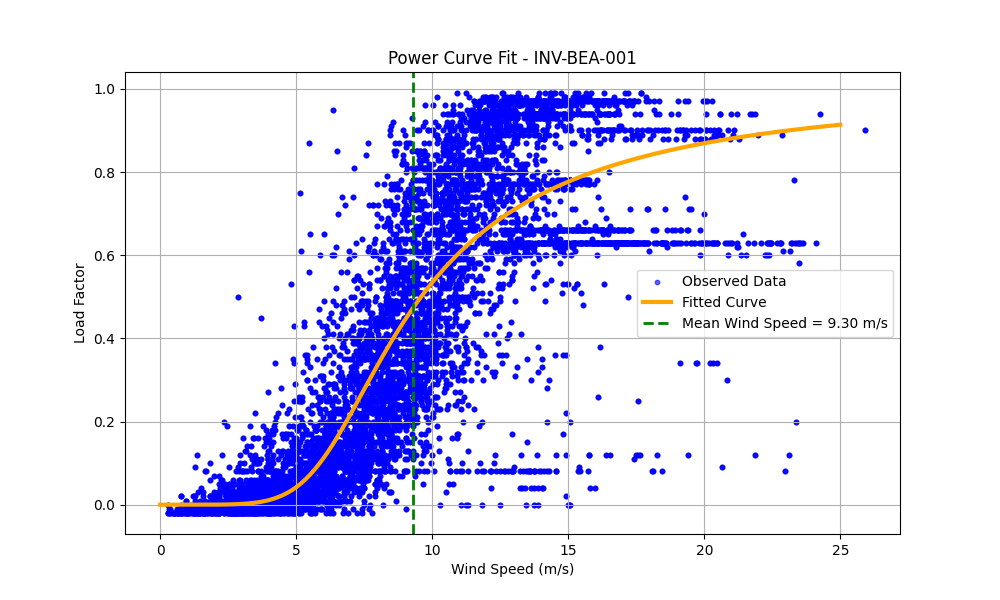

### PowerCurveFit_INV-BEA-002.png

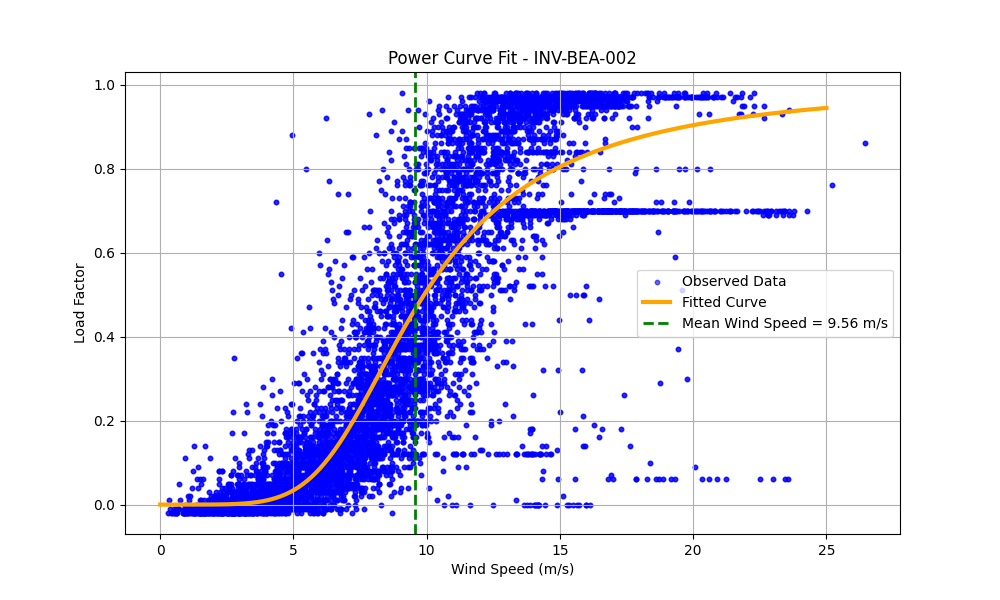

### PowerCurveFit_INV-BUR-001.png

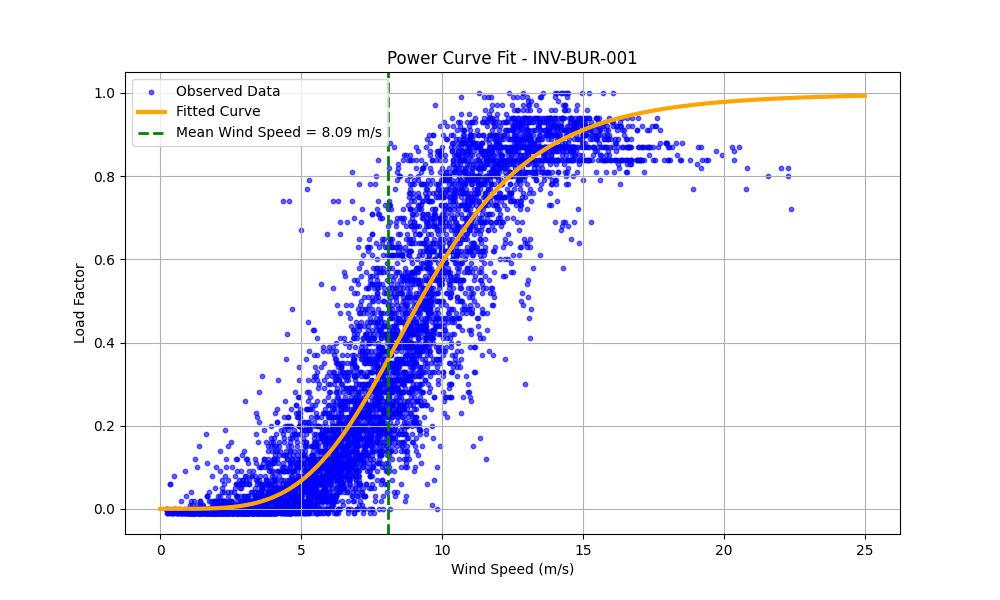

### PowerCurveFit_INV-DUD-001.png

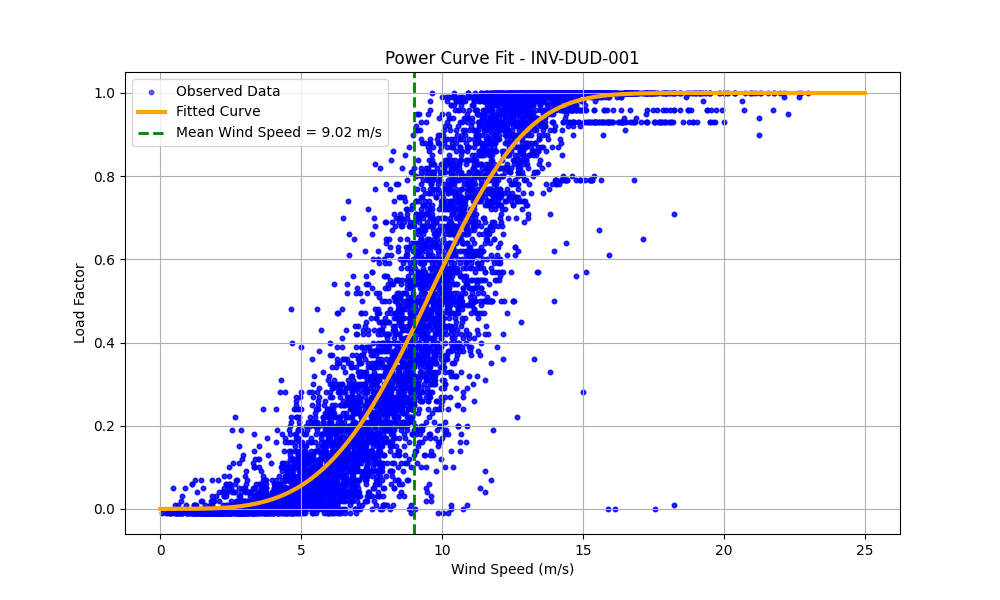

### PowerCurveFit_INV-DUD-002.png

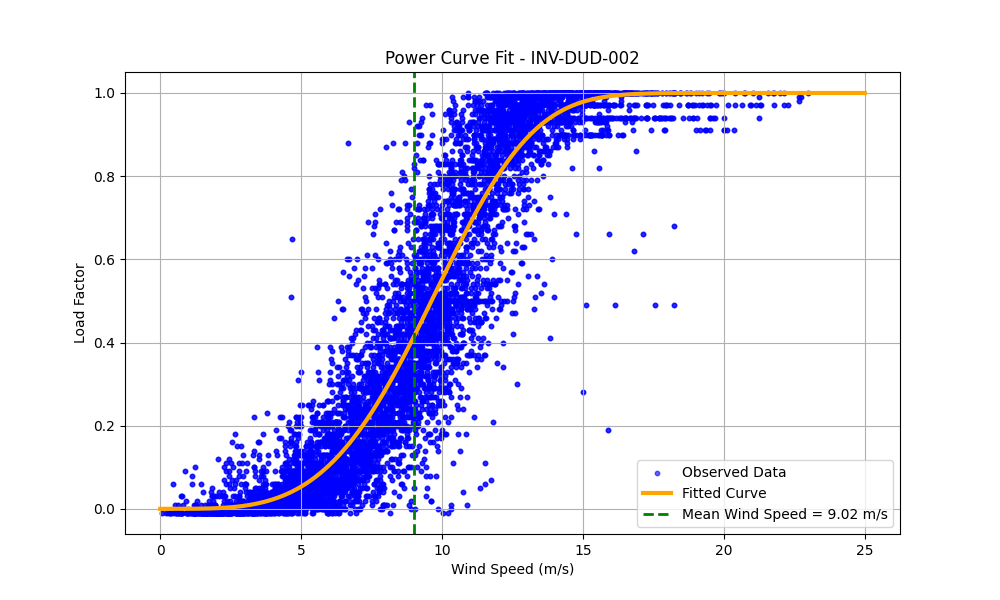

### PowerCurveFit_INV-DUD-003.png

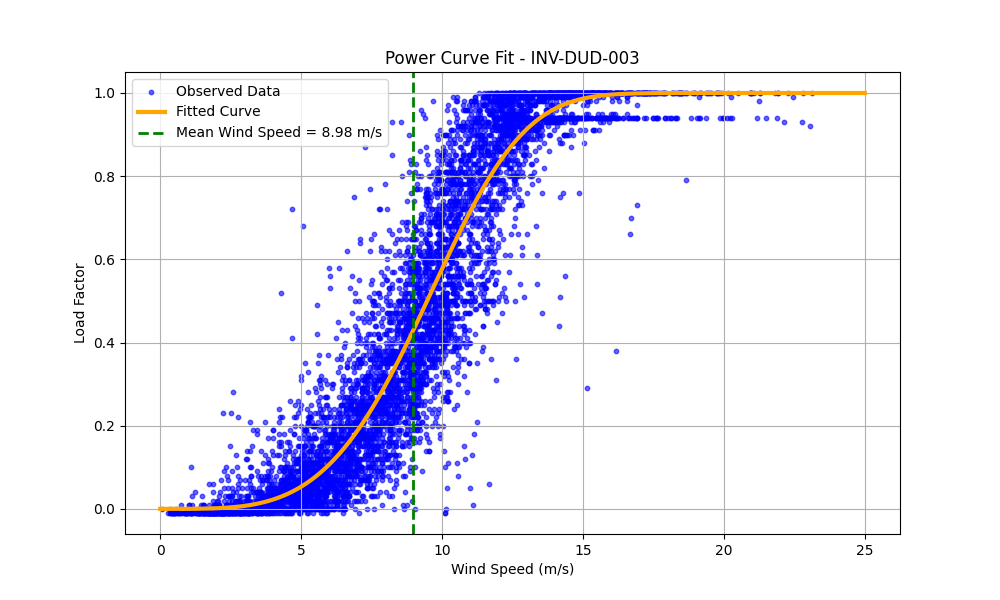

### PowerCurveFit_INV-HOR-001.png

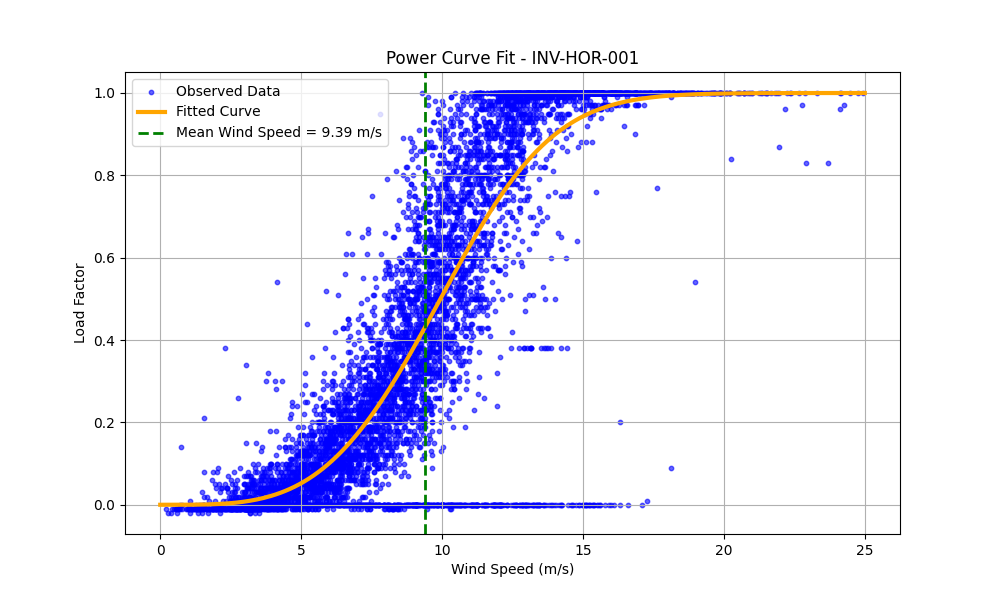

### PowerCurveFit_INV-HOR-002.png

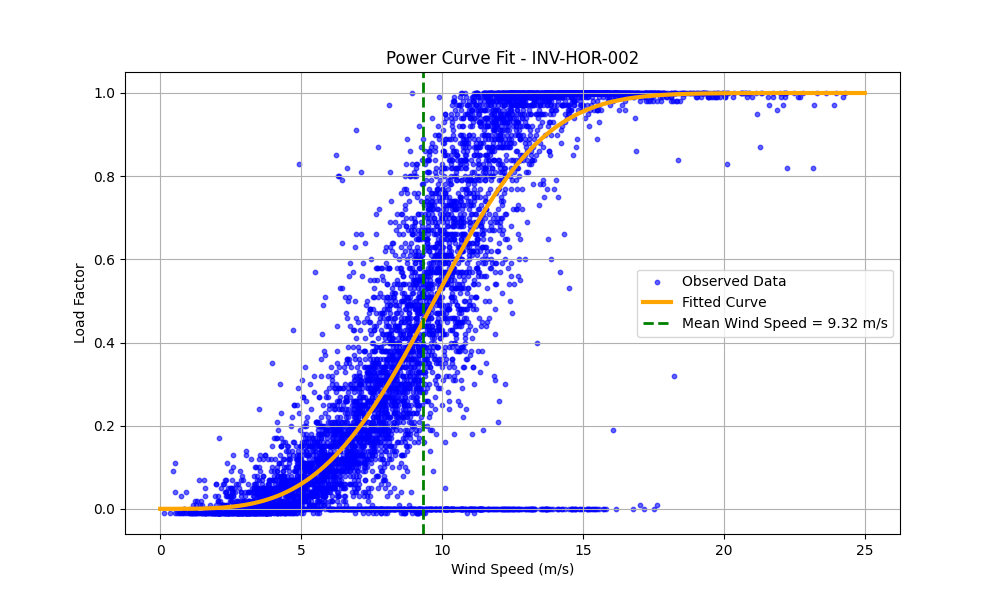

### PowerCurveFit_INV-HOR-003.png

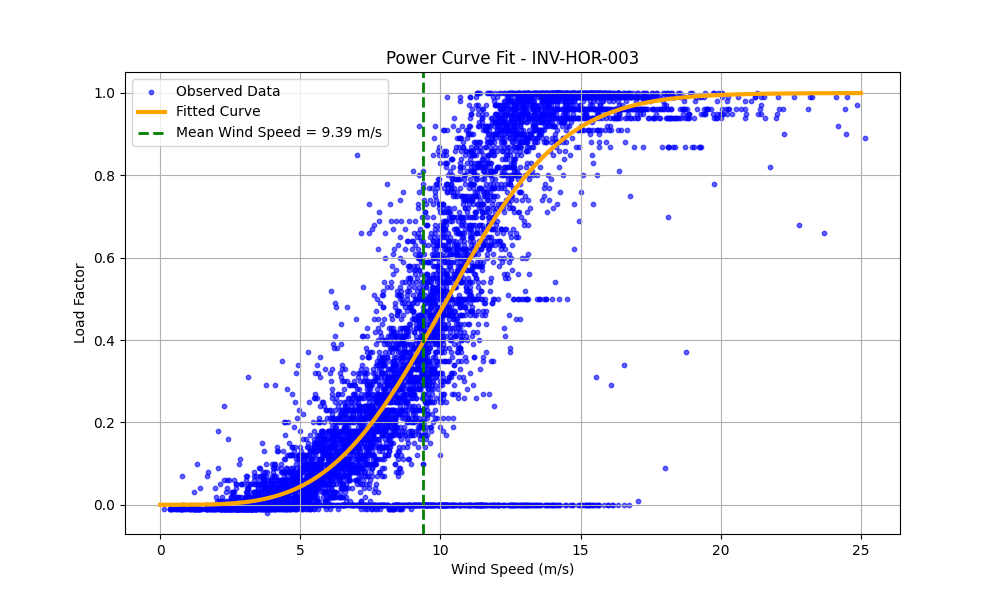

### PowerCurveFit_INV-WAL-001.png

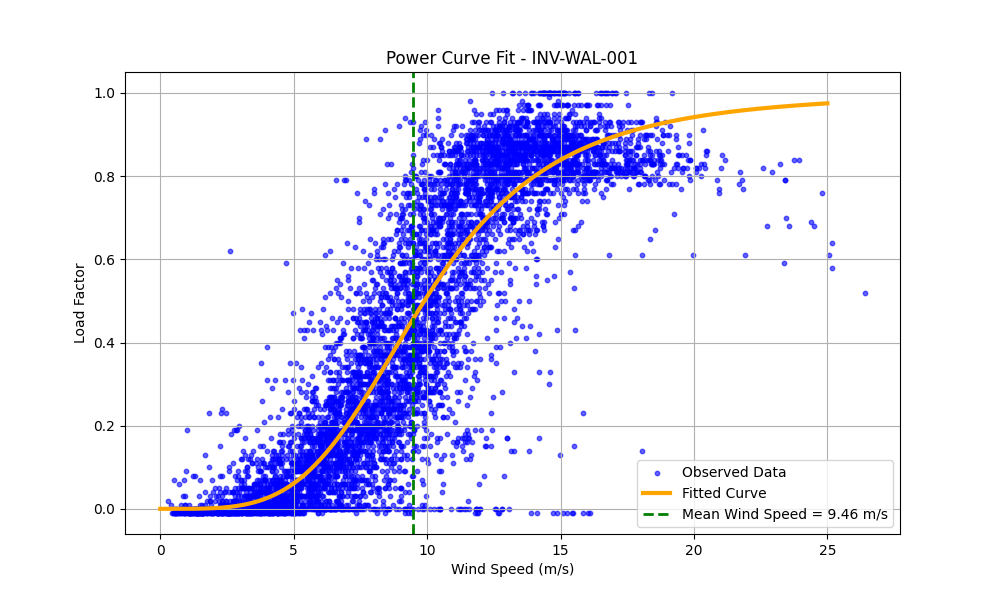

### PowerCurveFit_INV-WAL-002.png

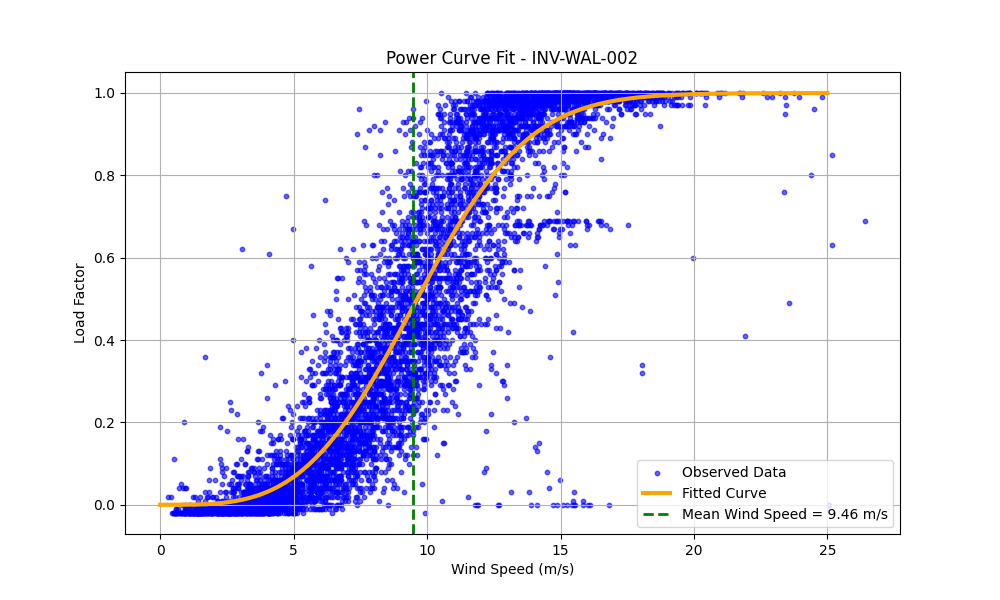

In [15]:
from pathlib import Path

from IPython.display import Image, Markdown, display

png_files = sorted(Path(OUTPUT_PATH).glob("PowerCurveFit_*.png"))

if not png_files:
    print("No PNG files found.")
else:
    print(f"Found {len(png_files)} PNG files.\n")
    for png in png_files:
        display(Markdown(f"### {png.name}"))
        display(Image(filename=str(png)))

## 7) Basic Troubleshooting

### ERA5 / NetCDF loading issues

If you see warnings like "Failed to load ... xarray IO backends ...":

1. Confirm dependencies are installed (including notebook extras):
   - `uv sync --group notebook`
2. Verify `netCDF4` is importable and print versions:
3. Try opening one ERA5 file with `engine='netcdf4'` (cell above).
4. Confirm `.nc` files are in `data/era5/` and not corrupted.

If no files load successfully, `WindCalibrator` raises: `ValueError: Failed to load any NetCDF files successfully`.

In [16]:
import importlib

for pkg in ["xarray", "netCDF4", "h5netcdf"]:
    spec = importlib.util.find_spec(pkg)
    print(f"{pkg}:", "installed" if spec else "missing")

xarray: installed
netCDF4: installed
h5netcdf: missing


### Other quick checks

- Missing plant file: `data/plant/plant_data.csv`
- Missing generation file: `data/generation/generation_data.parquet`
- Missing ERA5 directory/files: `data/era5/*.nc`
- Permission issues writing output: ensure `output_path` is writable